In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pandas as pd
import re
import rasterio
import random
from rasterio.transform import from_origin
from pyproj import Transformer
import re
import scipy as sp
import pyreadr
import sys
sys.path.append(os.path.abspath('../src/'))
from utils import *
from scipy import stats
import argparse
import copy
import glob
import argparse
import cProfile
import csv
from functools import partial
import itertools
import math
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import rasterio
from scipy import stats
from scipy.optimize import minimize
# from scipy.special import binom
from skimage import graph
import sys
import time
from tqdm import tqdm
import numpy.ma as ma
import warnings
import numpy as np
import psutil
import gc

warnings.filterwarnings("ignore")

import logging
logging.getLogger("distributed").setLevel(logging.ERROR)


Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


### Random Grid Generations

In [23]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/1000m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/traps_to_remove_1km.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_1km"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"   # ID column used for selection
trap_index_col = "Trap_index"  # Column to output in excluded files

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Save selected traps (original format)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_df.to_csv(selected_path, index=False)

        # Excluded traps — only trap_index column
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]

        excluded_only_index = excluded_df[[trap_index_col]]

        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap and excluded trap-index files generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [24]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/500m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/traps_to_remove_UTM10N_updated.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_500m"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"    # Used for filtering & selection

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps (random sample)
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Keep only the Trap_index column for selected traps
        selected_only_index = selected_df[[trap_id_col]]

        # Save selected traps as .txt (one per line, no header)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_only_index.to_csv(selected_path, index=False, header=False)

        # Excluded traps — from original grid_df
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]
        excluded_only_index = excluded_df[[trap_id_col]]

        # Save excluded traps as .txt
        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap ID .txt files (selected & excluded) generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [25]:
grid_df

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


### Forward Greedy SECR File Generation

In [26]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG36/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG36/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:70]  # Limit to first 70 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG36/selected_traps.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('full_grid_500m/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG36/FG36-excluded_traps-70.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 70 traps
Excluded 2367 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


### Selected Traps Heat Map

In [27]:
parent_dir = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Forward Greedy'
folders = [f'FG{i}' for i in range(48, 54)]

all_data = []
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        all_data.append(df)
df_all = pd.concat(all_data, ignore_index=True)

# Count how many times each Trap_index was selected
trap_counts = df_all['Trap_index'].value_counts().reset_index()
trap_counts.columns = ['Trap_index', 'count']

# Load candidate traps (includes x, y, Prior_cam, Trap_index)
candidate_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
df_candidates = pd.read_csv(candidate_path)

# Ensure Trap_index columns are numeric and clean
df_candidates['Trap_index'] = pd.to_numeric(df_candidates['Trap_index'], errors='coerce')
trap_counts['Trap_index'] = pd.to_numeric(trap_counts['Trap_index'], errors='coerce')

df_candidates = df_candidates.dropna(subset=['Trap_index']).copy()
trap_counts = trap_counts.dropna(subset=['Trap_index']).copy()

df_candidates['Trap_index'] = df_candidates['Trap_index'].astype(int)
trap_counts['Trap_index'] = trap_counts['Trap_index'].astype(int)

# Merge candidate data (with x, y, Prior_cam) and counts on Trap_index
result = pd.merge(df_candidates, trap_counts, on='Trap_index', how='right')

# Select desired columns: coordinates come from candidates file now
result = result[['Trap_index', 'x', 'y', 'Prior_cam', 'count']]

# Save result or print preview
result.to_csv('trap_id_selection_count.csv', index=False)

result2 =result[result['Prior_cam'] == 0]
result2.to_csv('trap_id_selection_count_NEW_CAMS.csv', index=False)

In [28]:
result2

,Trap_index,x,y,Prior_cam,count
21,1041,493483.355444,5.651120e+06,0,5
22,717,521860.089284,5.640515e+06,0,5
23,128,517949.862830,5.658720e+06,0,5
24,1038,491343.699278,5.652666e+06,0,5
25,897,493720.995156,5.640971e+06,0,5
26,1382,489361.621824,5.654703e+06,0,5
76,1151,492082.054012,5.660346e+06,0,4
77,974,494935.326961,5.663344e+06,0,4
78,1189,493761.232891,5.662357e+06,0,4
79,906,495622.062750,5.642457e+06,0,3


In [29]:
# how many unique proposed layouts of traps are there? essentially, determine the unique combinations of Trap_index that appear in each of the selected_traps.csv files

# for each selected_traps.csv file, return the selected trap indices as a set, then convert the list of sets to a set of frozensets to get unique combinations
unique_combinations = set()
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        unique_combinations.add(frozenset(df['Trap_index'].unique()))
# Count the number of unique combinations
num_unique_combinations = len(unique_combinations)
print(f'Number of unique trap combinations: {num_unique_combinations}')
# # Print the unique combinations
# print(f'Unique trap combinations: {unique_combinations}')


# let me know the folder names that have each of the unique combinations
combination_to_folders = {comb: [] for comb in unique_combinations}
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        comb = frozenset(df['Trap_index'].unique())
        combination_to_folders[comb].append(folder)
# Print the folder names for each unique combination
for comb, folder_list in combination_to_folders.items():
    print(f'Combination: {comb}, Folders: {folder_list}')
# Save the unique combinations and their corresponding folders to a CSV fil


Number of unique trap combinations: 3
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1382', '1397', '1463', '1425', '1460', '1189', '1151', '1396', '1414', '1404', '1437', '1438', '1415', '1405', '1408', '1451', '1403', '1418', '1423', '1419', '128', '1429', '1465', '1424', '1411', '1038', '1401', '1412', '717', '1443', '1432', '1445', '1452', '897', '1442', '1420', '1399', '974', '1458', '1426', '1464', '1431', '1440', '1417', '1457', '1410', '1441', '1446', '1459', '1435', '1454', '1433', '1447'}), Folders: ['FG50', 'FG52']
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '67', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1

In [30]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')
# Exclude nulls and values > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

plt.figure(figsize=(10, 6))
sns.violinplot(x='Configuration', y='Absolute Error N', data=df_filtered, inner='box')
plt.yscale('log')  # Apply logarithmic scaling to y axis
plt.title('Violin Plot of Absolute Error N by Configuration (Log Scale)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N (log scale)')
plt.tight_layout()
plt.show()



NameError: name 'sns' is not defined

<Figure size 720x432 with 0 Axes>

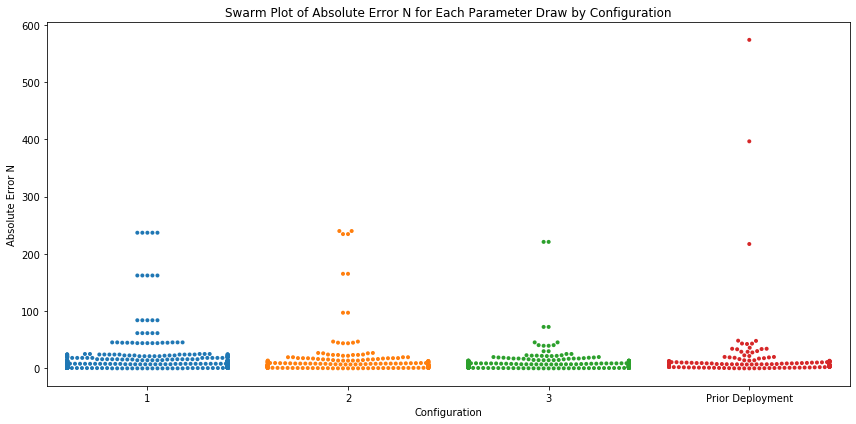

In [ ]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')

df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 1000]

df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

# Plot a swarm plot with all 150 parameter draw values per configuration
plt.figure(figsize=(12, 6))
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=4
)
plt.title('Swarm Plot of Absolute Error N for Each Parameter Draw by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()



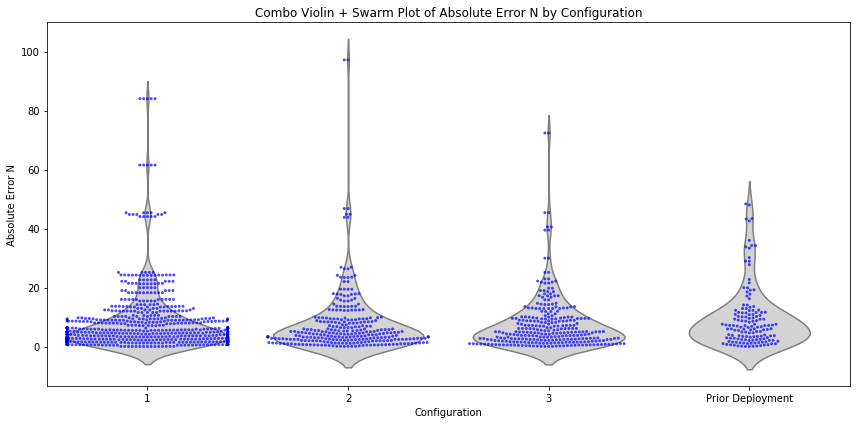

In [ ]:

# Exclude missing values and 'Absolute Error N' > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

# Convert "Configuration" to string for clear labels
df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

plt.figure(figsize=(12, 6))
# Plot the violin plot
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    inner=None,      # Hide internal marks so swarm plot is clear
    color='lightgray'
)
# Overlay the swarm plot
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Combo Violin + Swarm Plot of Absolute Error N by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


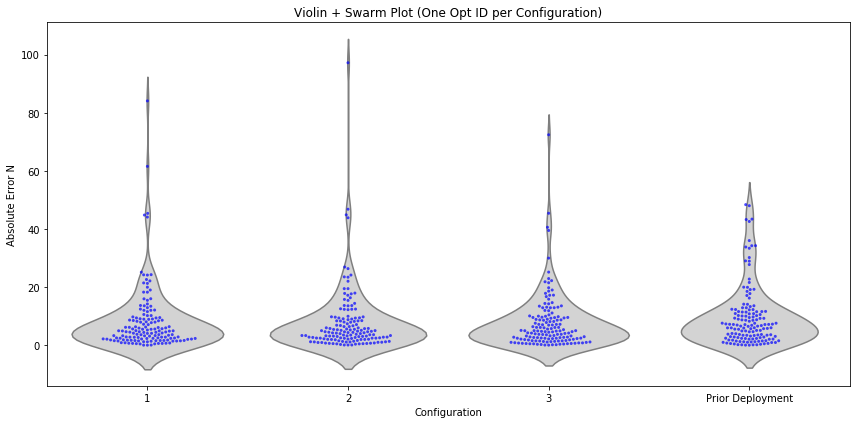

In [ ]:
# For each configuration, pick ONE opt id (here: the first opt ID encountered for each configuration)
chosen = df_filtered.groupby('Configuration')['Optimization ID'].first().reset_index()
# Filter DF to keep only those Opt IDs
filtered_one_per_config = df_filtered.merge(chosen, on=['Configuration', 'Optimization ID'])

# Plot violin+swarm using only one Opt ID per configuration
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    inner=None,
    color='lightgray'
)
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Violin + Swarm Plot (One Opt ID per Configuration)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


### Forward Greedy with Base

In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates as numpy array
coords = traps_df[['x', 'y']].to_numpy()

# Calculate the pairwise distance matrix
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs once (i < j to avoid duplicates)
unique_pairs = [
    (int(traps_df.iloc[i]['Trap_index']), int(traps_df.iloc[j]['Trap_index']))
    for i, j in zip(pairs[0], pairs[1]) if i < j
]

# Example: print the results
for pair in unique_pairs:
    print(pair)


(1, 29)
(1, 778)
(1, 779)
(1, 780)
(1, 809)
(2, 35)
(2, 36)
(2, 37)
(2, 783)
(2, 785)
(2, 808)
(3, 19)
(3, 788)
(3, 789)
(3, 790)
(3, 792)
(3, 1310)
(4, 22)
(4, 510)
(4, 511)
(4, 955)
(4, 966)
(5, 551)
(5, 552)
(5, 569)
(5, 572)
(5, 1363)
(5, 1364)
(6, 7)
(6, 350)
(6, 353)
(6, 401)
(6, 404)
(6, 1354)
(7, 8)
(7, 350)
(7, 351)
(7, 353)
(7, 354)
(8, 351)
(8, 352)
(8, 354)
(8, 712)
(9, 27)
(9, 522)
(9, 523)
(9, 524)
(9, 960)
(10, 11)
(10, 494)
(11, 422)
(12, 568)
(12, 570)
(12, 571)
(12, 573)
(12, 575)
(12, 576)
(12, 1028)
(12, 1029)
(12, 1364)
(12, 1365)
(13, 14)
(13, 421)
(13, 422)
(13, 427)
(13, 429)
(14, 421)
(14, 502)
(14, 503)
(15, 16)
(15, 498)
(15, 500)
(15, 501)
(15, 502)
(15, 503)
(15, 574)
(15, 579)
(15, 1366)
(16, 17)
(16, 502)
(16, 503)
(16, 504)
(17, 502)
(17, 503)
(17, 504)
(18, 625)
(18, 972)
(18, 1308)
(19, 611)
(19, 789)
(19, 790)
(19, 792)
(19, 1310)
(20, 21)
(20, 611)
(20, 612)
(20, 789)
(20, 792)
(20, 793)
(20, 1309)
(21, 611)
(21, 612)
(21, 789)
(21, 792)
(21, 793)
(2

In [ ]:
print(len(unique_pairs), "pairs found within 500m distance.")

3392 pairs found within 500m distance.


In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates and indices
coords = traps_df[['x', 'y']].to_numpy()
trap_indices = traps_df['Trap_index'].to_numpy()

# Calculate pairwise distances
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs with i < j to avoid duplicates
unique_pairs = [(i, j) for i, j in zip(pairs[0], pairs[1]) if i < j]

# Track cameras to remove (we will remove the second camera in each pair)
to_remove_indices = set(j for i, j in unique_pairs)

# Alternative: if you want a deterministic removal to avoid removing multiple times,
# you can also do a greedy approach removing cameras, but the above is simplest

# Indices of cameras to keep
all_indices = set(range(len(traps_df)))
to_keep_indices = all_indices - to_remove_indices

# Filter original dataframe by kept indices
remaining_cameras = traps_df.iloc[list(to_keep_indices)]

print(f"Number of cameras before removal: {len(traps_df)}")
print(f"Number of cameras after removal: {len(remaining_cameras)}")

# Optional: Save remaining cameras to a new CSV
# remaining_cameras.to_csv('remaining_cameras.csv', index=False)


Number of cameras before removal: 1465
Number of cameras after removal: 288


In [ ]:
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')
ac_coords = ac_coords[None]
ac_coords_list = ac_coords[['x', 'y']].values.tolist()
ac_coords_list = np.array(ac_coords_list)
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [ ]:
# what x,y coords in scrpy/pgaff-testing/secr/Prior Deployment/deployed_cams_2024.csv are not in the scrpy/pgaff-testing/only_trail/500m/trail_candidate_traps_spacing500.csv?

deployed_cams = pd.read_csv('./secr/Prior Deployment/P1/deployed_cams_2024.csv')
deployed_cams_coords = deployed_cams[['x', 'y']].values.tolist()
deployed_cams_coords = np.array(deployed_cams_coords)

candidate_cams = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv')
candidate_cams_coords = candidate_cams[['x', 'y']].values.tolist()
candidate_cams_coords = np.array(candidate_cams_coords)
# Find the coordinates in deployed_cams_coords that are not in candidate_cams_coords
missing_coords = []
for coord in deployed_cams_coords:
    if not any(np.array_equal(coord, candidate_coord) for candidate_coord in candidate_cams_coords):
        missing_coords.append(coord)
missing_coords = np.array(missing_coords)
print(len(missing_coords))


68


In [ ]:
true_n = pd.read_csv('./only_trail_1km/True_N_per_draw.csv')
# valid_ids = true_n['Parameter_draw'].tolist()                               # Change this if you want to filter with parameter draws in between some values of N or g0

params = pd.read_csv('./only_trail_1km/param_values_for_each_draw150.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})
params = params.sample(n=50).reset_index(drop=True)                          # Randomly select 5 draws
# params = params[params['index'].isin(valid_ids)].iloc[:5]
print(f"Using {params['index'].tolist()} parameter draws")

D, g0, sigma = params['D'].values, params['g0'].values, params['sigma'].values
draw = params['index'].tolist()
draw_to_trueN = dict(zip(true_n['Parameter_draw'], true_n['N']))

# Gather all potential activity center locations
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')[None]
ac_coords_list = ac_coords[['x', 'y']].values

# Load full possible trap grid
full_trap_grid = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv').drop(columns=['Unnamed: 0'])
full_trap_grid = full_trap_grid.rename(columns={'X': 'x', 'Y': 'y'})

# Candidate traps after 50m accessibility filter
# excluded_ids = pd.read_csv('./500m_data/traps_to_remove_50m.csv')['TrapID']
# candidate_grid = full_trap_grid[~full_trap_grid['Trap_index'].isin(excluded_ids)].copy()
candidate_grid = full_trap_grid.copy()

# Load all 68 deployed traps
# deployed_df = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')
# deployed_df = deployed_df[['x', 'y', 'Trap_index']]  # assuming correct format from file
deployed_df = full_trap_grid[full_trap_grid['Prior_cam']==1].copy()
deployed_df

candidate_exclusive = candidate_grid[~candidate_grid['Trap_index'].isin(deployed_df['Trap_index'])][['x', 'y', 'Trap_index']]

candidate_exclusive

Using [4, 9, 18, 61, 107, 45, 95, 24, 49, 58, 106, 33, 131, 139, 40, 97, 85, 37, 80, 71, 109, 133, 31, 117, 146, 51, 67, 87, 65, 11, 89, 14, 122, 98, 137, 144, 26, 42, 62, 147, 53, 74, 88, 83, 8, 15, 141, 56, 66, 119] parameter draws


,x,y,Trap_index
0,510670.337539,5.634173e+06,1
1,510589.866136,5.636167e+06,2
2,511461.885975,5.637240e+06,3
3,516098.336526,5.638313e+06,4
4,514871.344999,5.641862e+06,5
...,...,...,...
1390,502867.143885,5.653349e+06,1391
1391,502779.344158,5.652899e+06,1392
1392,514477.896293,5.639606e+06,1393
1393,514898.265452,5.639352e+06,1394


### File Manipulation

In [ ]:
# put the Traps IDs that have a Prior_cam value of 0 into the txt file based on the data in scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv

# File paths
input_csv = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv"
output_txt = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt"

# Change these variables if your columns have different names
trap_id_column = 'Trap_index'     # Replace with the actual Trap ID column name
prior_cam_column = 'Prior_cam' # Replace with the actual Prior_cam column name

trap_ids = []

# Read the CSV and extract Trap IDs
with open(input_csv, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if row[prior_cam_column] == '0' or row[prior_cam_column] == 0:
            trap_ids.append(row[trap_id_column])

# Write Trap IDs to a txt file
with open(output_txt, 'w', encoding='utf-8') as txtfile:
    for trap_id in trap_ids:
        txtfile.write(f"{trap_id}\n")

print(f"Extracted {len(trap_ids)} Trap IDs to '{output_txt}'.")


Extracted 1395 Trap IDs to '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt'.


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG11/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 20:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 20 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG11/selected_traps-20.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG11/BG11-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# find the lat longs in scrpy/pgaff-testing/500m_data/SCM_deployed_cams_2024.csv that are not in 500m_trap_grid.csv
deployed_cams = pd.read_csv('deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})
# merge with trap_coords to find the traps that are not in the grid
deployed_cams = deployed_cams.merge(trap_coords, on=['x', 'y'], how='left')

In [ ]:
deployed_cams.to_csv('secr/Prior Deployment/deployed_cams_2024.csv', index=False)

In [ ]:
# Load the deployed cameras file and rename coordinate columns for consistency
deployed_cams = pd.read_csv('500m_data/SCM_deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})

# Load the full trap grid
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')

# Identify grid records (by x,y) that are not present in deployed cameras
not_in_deployed = trap_coords[
    ~trap_coords[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]

not_in_deployed

not_in_deployed['Trap_index'].to_csv('not_in_2019_deployment.txt', index=False, header=False)


# with open('secr/2019 Deployment/deployed_cams_not_in_grid.txt', 'w') as f:
#     for item in deployed_cams_not_in_grid['TrapID']:
#         f.write("%s\n" % item)

In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
# selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:

# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:68]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-68.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
trap_coords = pd.read_csv('./500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['TrapID'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")

trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])
trap_coords_list_df.to_csv('./secr/Random/R3/considered_trap_locs.csv', index=False)

# randomly select 68 of the trap locations
selected_traps = np.random.choice(trap_coords_list.shape[0], size=68, replace=False)
trap_coords_list_sub_df = trap_coords_list_df.iloc[selected_traps]


# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Random/R3/selected_traps.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Random/R3/R3-excluded_traps.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

(258, 2) candidate trap locations
Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
exclude_trap_coords

,TrapID,X,Y
0,1,509737.787215,5.633510e+06
1,2,510237.787215,5.633510e+06
2,3,510737.787215,5.633510e+06
3,4,511237.787215,5.633510e+06
4,5,509237.787215,5.634010e+06
...,...,...,...
2174,2433,496737.787215,5.663510e+06
2175,2434,489737.787215,5.664010e+06
2176,2435,490237.787215,5.664010e+06
2177,2436,490737.787215,5.664010e+06


### Costing Surfaces

In [ ]:
traps = pd.read_csv('./500m_data/500m_trap_grid.csv')
deployed_cams = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')

# Identify traps that are not in deployed_cams
not_in_deployed = traps[
    ~traps[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]
not_in_deployed

not_in_deployed.to_csv('traps_to_remove_prior.csv')

In [ ]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 500
costing_surface_allowed = costing_surface[~(costing_surface['rel_cost'].isna()) & ~(costing_surface['Distance_to_trail_m'] > 500.00)]
costing_surface_allowed

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
60,61,61,431.303809,916.542688,0.081414,508737.7872,5637010.469
61,62,62,361.697779,861.470553,0.076522,509237.7872,5637010.469
62,63,63,376.082558,818.130720,0.072672,509737.7872,5637010.469
63,64,64,370.426454,864.657365,0.076805,510237.7872,5637010.469
65,66,66,441.168219,877.416023,0.077938,511237.7872,5637010.469
...,...,...,...,...,...,...,...
2428,2429,2429,248.762323,3529.317834,0.313499,494737.7872,5663510.469
2429,2430,2430,116.778259,3468.382344,0.308086,495237.7872,5663510.469
2430,2431,2431,25.001649,3496.168778,0.310554,495737.7872,5663510.469
2431,2432,2432,252.564797,3635.222101,0.322906,496237.7872,5663510.469


In [ ]:
# from selected_traps.csv in FG11, return a csv that has just the x,y coordinates of those that are not in deployed_cams_2024.csv
selected_traps = pd.read_csv('secr/Forward Greedy/FG11/selected_traps-20.csv')


In [29]:
ac_files = glob.glob('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/Constant_detection/AC_locations/*.csv')


ac_coords = []
for file in ac_files:
    df = pd.read_csv(file)
    if 'x' in df.columns and 'y' in df.columns:
        ac_coords.append(df[['x', 'y']])

ac_coords_df = pd.concat(ac_coords, ignore_index=True)

ac_coords_df.to_csv('combined_ac_coords_10-3_marten.csv', index=False)
print("Combined coordinates saved")


Combined coordinates saved


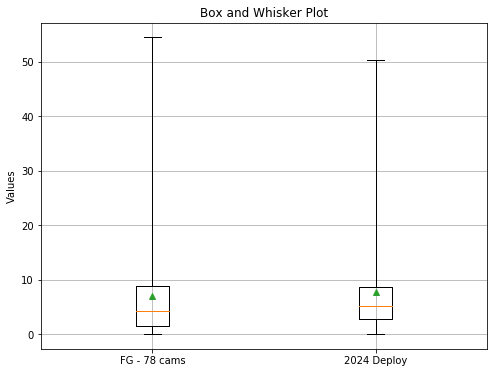

In [ ]:
import matplotlib.pyplot as plt

# Summary statistics
labels = ['FG - 78 cams', '2024 Deploy']
min_vals = [0.049, 0.026]
q1 = [1.54, 2.72]
median = [4.22, 5.08]
q3 = [8.77, 8.58]
max_vals = [54.47, 50.25]
means = [6.97, 7.76]

# Prepare boxplot data for matplotlib's bxp() function
box_data = []
for i in range(len(labels)):
    box_data.append({
        'label': labels[i],
        'whislo': min_vals[i],     # Lower whisker (min)
        'q1': q1[i],               # First quartile (Q1)
        'med': median[i],          # Median (Q2)
        'q3': q3[i],               # Third quartile (Q3)
        'whishi': max_vals[i],     # Upper whisker (max)
        'mean': means[i],          # Mean (optional)
        'fliers': []               # No outliers available
    })

# Create the box and whisker plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bxp(box_data, showmeans=True)
ax.set_ylabel('Values')
ax.set_title('Box and Whisker Plot')
ax.grid(True)
plt.show()


In [ ]:
# add the data from all the files in AC_locations into a singular csv file.


In [ ]:
costing_surface_disallowed = costing_surface[(costing_surface['rel_cost'].isna()) | (costing_surface['Distance_to_trail_m'] > 500.00)]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['Trap_index', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_cost_500m.csv', index=False)

In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 50
costing_surface_allowed = costing_surface[~(costing_surface['Rel_cost'].isna())]
costing_surface_allowed


costing_surface_disallowed = costing_surface[(costing_surface['Rel_cost'].isna())]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['TrapID', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_50m.csv', index=False)

In [ ]:
costing_surface

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
0,1,1,3842.015535,NaN,NaN,509737.7872,5633510.469
1,2,2,3855.952509,NaN,NaN,510237.7872,5633510.469
2,3,3,3874.371793,NaN,NaN,510737.7872,5633510.469
3,4,4,3822.221227,NaN,NaN,511237.7872,5633510.469
4,5,5,3355.109326,NaN,NaN,509237.7872,5634010.469
...,...,...,...,...,...,...,...
2432,2433,2433,171.146726,3789.301023,0.336592,496737.7872,5663510.469
2433,2434,2434,4130.440150,NaN,NaN,489737.7872,5664010.469
2434,2435,2435,3668.201922,NaN,NaN,490237.7872,5664010.469
2435,2436,2436,3217.277553,NaN,NaN,490737.7872,5664010.469


In [ ]:
import numpy as np

def average_diff_and_abs_diff_for_iteration(file_path, iteration_num):
    """
    Returns both the average error (Diff, signed)
    and the average absolute error (|Diff|) for the given iteration.
    """
    diffs = []
    with open(file_path, 'r') as f:
        found_iter = False
        target_iter_line = f"Iteration {iteration_num}:"
        for line in f:
            if line.strip().startswith(target_iter_line):
                found_iter = True
                continue
            if found_iter:
                if line.strip().startswith('Iteration'):
                    # Reached next iteration, stop reading further
                    break
                if 'Diff=' in line:
                    try:
                        diff_value = float(line.split('Diff=')[1].strip())
                        diffs.append(diff_value)
                    except ValueError:
                        continue
    if not diffs:
        print(f"No 'Diff' values found for iteration {iteration_num}.")
        return None, None
    average_error = np.mean(diffs)
    average_abs_error = np.mean(np.abs(diffs))
    print(f"Average Error for iteration {iteration_num}: {average_error}")
    print(f"Average Absolute Error for iteration {iteration_num}: {average_abs_error}")
    return average_error, average_abs_error

# Example usage:
file_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Backward Greedy/BG8/n_tracker.txt'
iteration_num = 238  # Change to desired iteration
average_diff_and_abs_diff_for_iteration(file_path, iteration_num)


Average Error for iteration 238: -32.418700740400105
Average Absolute Error for iteration 238: 32.418700740400105


(-32.418700740400105, 32.418700740400105)

In [ ]:
# In each capture history file, determine what individuals and how many were observed.
def get_individuals(capture_history_file):
    """
    Return the unique number of individuals in the 'individual' column
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individuals = set()
        for row in reader:
            individual = row['individual']
            individuals.add(individual)
    return individuals

def get_recaptures(capture_history_file):
    """
    Return the number of individuals that have been captured more than once.
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individual_counts = {}
        for row in reader:
            individual = row['individual']
            if individual in individual_counts:
                individual_counts[individual] += 1
            else:
                individual_counts[individual] = 1
        # Count individuals with more than one capture
        recaptures = sum(1 for count in individual_counts.values() if count > 1)
    return recaptures


def get_spatial_recaptures(capture_history_file):
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)        
        individual_locations = {}
        for row in reader:
            indv = row['individual']
            loc = (row['trap_id'])
            if indv not in individual_locations:
                individual_locations[indv] = set()
            individual_locations[indv].add(loc)
        
        # Count individuals with >1 unique location
        return sum(1 for locs in individual_locations.values() if len(locs) > 1)


# run for all the files in pgaff-testing/500m_data/capture_history/
def process_capture_history_files(directory):
    """
    Process all capture history files in the given directory.
    """
    results = []
    for filename in tqdm(os.listdir(directory)):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            individuals = get_individuals(file_path)
            recaptures = get_recaptures(file_path)
            spatial_recaptures = get_spatial_recaptures(file_path)
            results.append({
                'file': filename,
                'individuals': len(individuals),
                'recaptures': recaptures,
                'spatial_recaptures': spatial_recaptures           
                })
    # return results as a dataframe with the number at the end of the cpature history file then the unique individuals detected in the other column
    results_df = pd.DataFrame(results)
    results_df['capture_history'] = results_df['file'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else None)
    # convert both columsn to integers
    results_df['capture_history'] = results_df['capture_history'].astype(int)
    results_df = results_df[['capture_history', 'individuals', 'recaptures', 'spatial_recaptures']]
    results_df['observations'] = results_df['individuals'].astype(int)
    results_df['recaptures'] = results_df['recaptures'].astype(int)
    results_df['spatial_recaptures'] = results_df['spatial_recaptures'].astype(int)
    results_df = results_df.sort_values(by='capture_history')
    results_df.reset_index(drop=True, inplace=True)
    # Save the results to a CSV file
    output_file = os.path.join(directory, 'individuals_observed.csv')
    results_df.to_csv(output_file, index=False)
    return results_df

process_capture_history_files('only_trail_1km/500m/ch')  # Adjust the path as needed

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:03<00:00, 40.51it/s]


,capture_history,individuals,recaptures,spatial_recaptures,observations
0,1,49,41,41,49
1,2,22,18,18,22
2,3,51,51,51,51
3,4,80,75,75,80
4,5,23,17,17,23
...,...,...,...,...,...
145,146,45,39,39,45
146,147,77,70,70,77
147,148,20,18,17,20
148,149,34,30,30,34


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG3/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG3/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG3/selected_traps_20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG3/FG3-excluded_traps_20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG8/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 68:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 68 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG8/selected_traps-68.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG8/BG8-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [33]:
trap_coords = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
# exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
exclude_trap_coords = pd.read_csv('./full_grid_1km/traps_to_remove_1km.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['Trap_index'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")
trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])

base_dir = './secr/Forward Greedy/FGM1'

selected_traps = [621, 586, 620, 656, 655, 654, 690, 691, 657, 812, 622, 811, 777, 776, 658, 
                    624, 623, 659, 625, 660, 689, 693, 694, 692, 986, 619, 695, 682, 653, 618, 583, 584,
                     585, 582, 617, 847, 775, 446, 626, 661, 696, 587, 683, 648, 741, 649, 647, 681, 1021, 481, 
                     447, 482, 480, 445, 479, 969, 26, 650, 684, 614, 615, 616, 651, 685, 652, 613, 866, 686, 784, 688, 1022, 987, 742, 61, 62, 27, 97, 96, 590, 591]

# Use trap_coords DataFrame which contains trap IDs

for n_cams in [10, 20, 30, 40, 50, 60, 70, 80]:
    traps_subset = selected_traps[:n_cams]

    trap_coords_list_sub_df = trap_coords[trap_coords['Trap_index'].isin(traps_subset)].copy()
    trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df['Trap_index']  # Keep IDs as-is

    trap_csv_path = f'{base_dir}/selected_traps_{n_cams}.csv'
    trap_coords_list_sub_df.to_csv(trap_csv_path, index=False)  # Index can be False if IDs are in data

    all_trap_ids = set(trap_coords['Trap_index'])
    selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])
    excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

    excluded_txt_path = f'{base_dir}/FGM1-excluded_traps-{n_cams}.txt'
    with open(excluded_txt_path, 'w') as f:
        for item in excluded_trap_ids:
            f.write(f"{item}\n")

    print(f"[{n_cams} cams] Selected {len(traps_subset)} traps, "
          f"Excluded {len(excluded_trap_ids)} traps, "
          f"Total traps in full grid: {len(all_trap_ids)}")
    print(f"   Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} = {len(all_trap_ids)}")



(1023, 2) candidate trap locations
[10 cams] Selected 10 traps, Excluded 1013 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[20 cams] Selected 20 traps, Excluded 1003 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[30 cams] Selected 30 traps, Excluded 993 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[40 cams] Selected 40 traps, Excluded 985 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[50 cams] Selected 50 traps, Excluded 975 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[60 cams] Selected 60 traps, Excluded 965 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[70 cams] Selected 70 traps, Excluded 955 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[80 cams] Selected 80 traps, Excluded 945 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023


In [ ]:
# for all the scnearios in scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv report E_n, E_r and if E_n or E_r is smaller.

params = pd.read_csv('./full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})

# Calculate E_n and E_r for each row


### Graphics for Papper

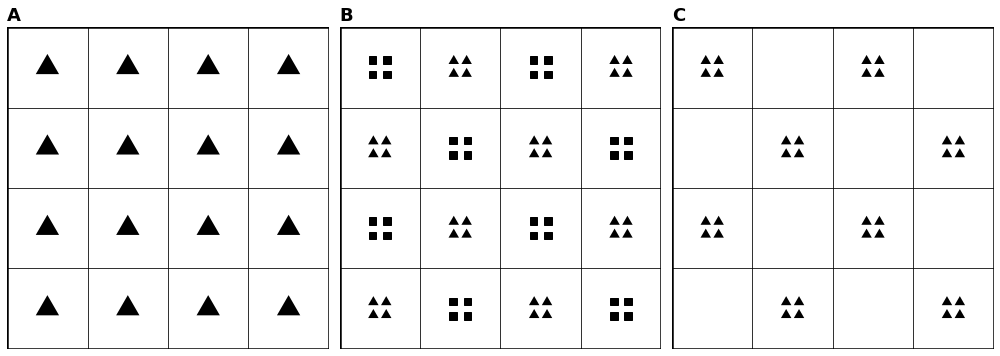

In [ ]:
def draw_triangle(ax, x_center, y_center, size=0.16):
    h = size * np.sqrt(3) / 2
    triangle = np.array([
        [x_center - size/2, y_center - h/3],
        [x_center + size/2, y_center - h/3],
        [x_center, y_center + 2*h/3]
    ])
    ax.fill(triangle[:, 0], triangle[:, 1], 'k')

def draw_2x2_triangles(ax, x_center, y_center, size=0.13, gap=0.06):
    # Draw a 2x2 grid of triangles centered at (x_center, y_center)
    offset = size / 1.3 + gap
    for dx in [-0.5, 0.5]:
        for dy in [-0.5, 0.5]:
            draw_triangle(ax,
                x_center + dx*offset,
                y_center + dy*offset,
                size)

def draw_window(ax, x_center, y_center, size=0.19):
    offset = size/2.1
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            ax.add_patch(
                patches.Rectangle(
                    (x_center + dx*offset - size/4, y_center + dy*offset - size/4),
                    size/2, size/2, color='k'
                )
            )

def make_grid(ax, n, border=0.13):
    ax.set_xlim(-border, n-1+border)
    ax.set_ylim(-border, n-1+border)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(-0.5, n, 1))
    ax.set_yticks(np.arange(-0.5, n, 1))
    ax.grid(True, which='both', color='black', linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    rec = patches.Rectangle((-0.5,-0.5), width=n, height=n,
                            linewidth=2.5, edgecolor='black',
                            facecolor='none')
    ax.add_patch(rec)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)

def plot_first_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_window(ax, j, n-1-i)
            else:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_second_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_third_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            draw_triangle(ax, j, n-1-i, size=0.29)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
plot_first_chart(axs[1])    # Chart A
plot_second_chart(axs[2])   # Chart B
plot_third_chart(axs[0])    # Chart C

# Add bold labels above each chart
labels = ['A', 'B', 'C']
for i, ax in enumerate(axs):
    ax.text(-0.5, 3.75, labels[i], fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('triangle_charts.png', dpi=300, bbox_inches='tight')
plt.show()


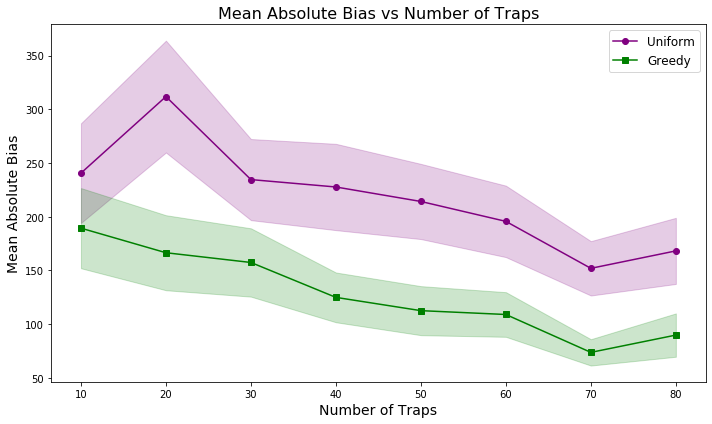

Paired t-test results per trap count:
Trap count 10: t-stat = 1.6057, p-value = 1.1376e-01
Trap count 20: t-stat = 5.1927, p-value = 1.2150e-06
Trap count 30: t-stat = 2.9709, p-value = 3.6675e-03
Trap count 40: t-stat = 4.4005, p-value = 2.4441e-05
Trap count 50: t-stat = 4.6387, p-value = 9.3482e-06
Trap count 60: t-stat = 4.5926, p-value = 1.1027e-05
Trap count 70: t-stat = 5.7082, p-value = 7.8530e-08
Trap count 80: t-stat = 4.0545, p-value = 8.5723e-05


In [27]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci


def process_uniform_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


def process_greedy_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


# Get data and pooled samples for t-tests
uniform_means, uniform_cis, uniform_pooled = process_uniform_data(uniform_folder, True)
greedy_means, greedy_cis, greedy_pooled = process_greedy_data(greedy_folder, True)


plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
plt.fill_between(
    trap_counts,
    np.maximum(uniform_means - uniform_cis, 0),
    uniform_means + uniform_cis,
    color='purple', alpha=0.2
)
plt.plot(trap_counts, greedy_means, marker='s', color='green', label='Greedy')
plt.fill_between(
    trap_counts,
    np.maximum(greedy_means - greedy_cis, 0),
    greedy_means + greedy_cis,
    color='green', alpha=0.2
)
plt.title('Mean Absolute Bias vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('Mean Absolute Bias', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# After plotting, output paired t-test results
print("Paired t-test results per trap count:")
for i, n in enumerate(trap_counts):
    uni_vals = uniform_pooled[i]
    gry_vals = greedy_pooled[i]
    min_len = min(len(uni_vals), len(gry_vals))
    if min_len < 2:
        print(f"Trap count {n}: Insufficient data for paired t-test")
        continue
    # Truncate for pairing
    uni_vals = uni_vals[:min_len]
    gry_vals = gry_vals[:min_len]
    t_stat, p_val = stats.ttest_rel(uni_vals, gry_vals)
    print(f"Trap count {n}: t-stat = {t_stat:.4f}, p-value = {p_val:.4e}")


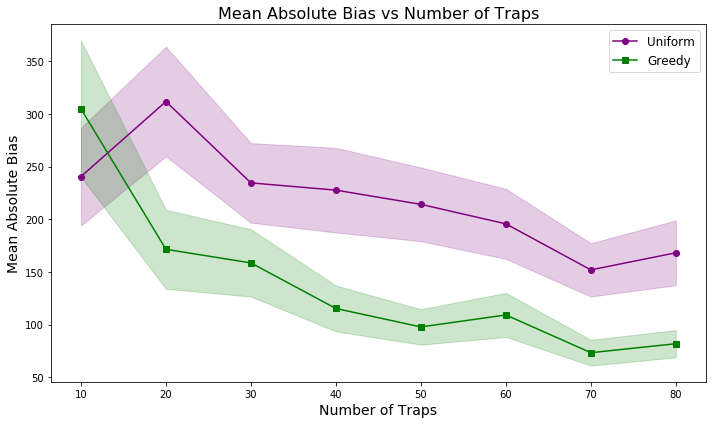

Paired t-test results per trap count:
Trap count 10: t-stat = -1.6381, p-value = 1.0690e-01
Trap count 20: t-stat = 4.2798, p-value = 4.5403e-05
Trap count 30: t-stat = 3.1422, p-value = 2.1694e-03
Trap count 40: t-stat = 4.9334, p-value = 2.7775e-06
Trap count 50: t-stat = 6.0213, p-value = 2.1204e-08
Trap count 60: t-stat = 4.6452, p-value = 8.8987e-06
Trap count 70: t-stat = 5.6642, p-value = 9.6376e-08
Trap count 80: t-stat = 5.4375, p-value = 2.5543e-07


In [47]:
####### SELECTED VIA RSE IN SAA####################
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/rse'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci


def process_uniform_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


def process_greedy_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


# Get data and pooled samples for t-tests
uniform_means, uniform_cis, uniform_pooled = process_uniform_data(uniform_folder, True)
greedy_means, greedy_cis, greedy_pooled = process_greedy_data(greedy_folder, True)


plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
plt.fill_between(
    trap_counts,
    np.maximum(uniform_means - uniform_cis, 0),
    uniform_means + uniform_cis,
    color='purple', alpha=0.2
)
plt.plot(trap_counts, greedy_means, marker='s', color='green', label='Greedy')
plt.fill_between(
    trap_counts,
    np.maximum(greedy_means - greedy_cis, 0),
    greedy_means + greedy_cis,
    color='green', alpha=0.2
)
plt.title('Mean Absolute Bias vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('Mean Absolute Bias', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# After plotting, output paired t-test results
print("Paired t-test results per trap count:")
for i, n in enumerate(trap_counts):
    uni_vals = uniform_pooled[i]
    gry_vals = greedy_pooled[i]
    min_len = min(len(uni_vals), len(gry_vals))
    if min_len < 2:
        print(f"Trap count {n}: Insufficient data for paired t-test")
        continue
    # Truncate for pairing
    uni_vals = uni_vals[:min_len]
    gry_vals = gry_vals[:min_len]
    t_stat, p_val = stats.ttest_rel(uni_vals, gry_vals)
    print(f"Trap count {n}: t-stat = {t_stat:.4f}, p-value = {p_val:.4e}")


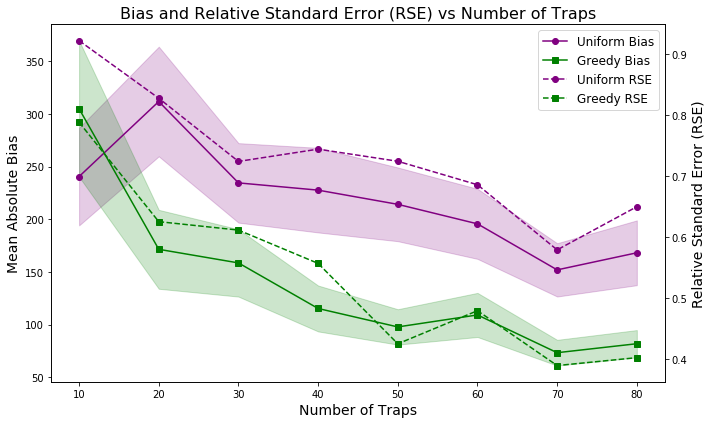

In [44]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Folder paths and trap counts (use your existing paths)
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Function for RSE confidence interval calculation
def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2

# Function for 95% CI calculation of mean values
def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

# Process RSE data for Uniform and Greedy
def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Process Mean Absolute Bias data for Uniform and Greedy
def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'  # Assuming this is the bias file path pattern
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Load all data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)

# Plotting with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Mean Absolute Bias with error bars on left y-axis
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple', label='Uniform Bias')
ax1.fill_between(trap_counts,
                 np.maximum(uniform_bias_means - uniform_bias_cis, 0),
                 uniform_bias_means + uniform_bias_cis,
                 color='purple', alpha=0.2)
ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green', label='Greedy Bias')
ax1.fill_between(trap_counts,
                 np.maximum(greedy_bias_means - greedy_bias_cis, 0),
                 greedy_bias_means + greedy_bias_cis,
                 color='green', alpha=0.2)

ax1.set_xlabel('Number of Traps', fontsize=14)
ax1.set_ylabel('Mean Absolute Bias', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis for RSE
ax2 = ax1.twinx()
ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple', linestyle='--', label='Uniform RSE')
# ax2.fill_between(trap_counts,
#                  np.maximum(uniform_rse_means - uniform_rse_cis, 0),
#                  uniform_rse_means + uniform_rse_cis,
#                  color='purple', alpha=0.1)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green', linestyle='--', label='Greedy RSE')
# ax2.fill_between(trap_counts,
#                  np.maximum(greedy_rse_means - greedy_rse_cis, 0),
#                  greedy_rse_means + greedy_rse_cis,
#                  color='green', alpha=0.1)

ax2.set_ylabel('Relative Standard Error (RSE)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=12, loc='upper right')

plt.title('Bias and Relative Standard Error (RSE) vs Number of Traps', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_combined_bias_rse.png', dpi=300, bbox_inches='tight')
plt.show()


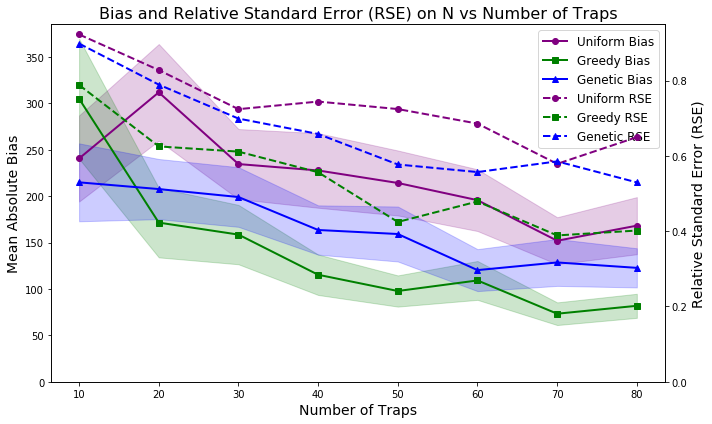

In [140]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Folder paths and trap counts
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Function for RSE confidence interval calculation
def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2

# Function for 95% CI calculation of mean values
def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

# Process RSE data for Uniform and Greedy (unchanged)
def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# NEW: Process Genetic Algorithm RSE data
def process_genetic_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Process Mean Absolute Bias data (same functions, just add Genetic)
def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_genetic_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Load all data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
genetic_rse_means, genetic_rse_cis = process_genetic_rse(genetic_folder)

uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)
genetic_bias_means, genetic_bias_cis = process_genetic_bias(genetic_folder)

# Plotting with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Mean Absolute Bias with error bars on left y-axis (solid lines)
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple', label='Uniform Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(uniform_bias_means - uniform_bias_cis, 0),
                 uniform_bias_means + uniform_bias_cis,
                 color='purple', alpha=0.2)
ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green', label='Greedy Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(greedy_bias_means - greedy_bias_cis, 0),
                 greedy_bias_means + greedy_bias_cis,
                 color='green', alpha=0.2)
ax1.plot(trap_counts, genetic_bias_means, marker='^', color='blue', label='Genetic Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(genetic_bias_means - genetic_bias_cis, 0),
                 genetic_bias_means + genetic_bias_cis,
                 color='blue', alpha=0.2)

ax1.set_xlabel('Number of Traps', fontsize=14)
ax1.set_ylabel('Mean Absolute Bias', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Force left y-axis to start at 0
y1_min, y1_max = ax1.get_ylim()
ax1.set_ylim(0, y1_max)

# Create a second y-axis for RSE (dashed lines)
ax2 = ax1.twinx()
ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple', linestyle='--', label='Uniform RSE', linewidth=2)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green', linestyle='--', label='Greedy RSE', linewidth=2)
ax2.plot(trap_counts, genetic_rse_means, marker='^', color='blue', linestyle='--', label='Genetic RSE', linewidth=2)

ax2.set_ylabel('Relative Standard Error (RSE)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Force right y-axis to start at 0
y2_min, y2_max = ax2.get_ylim()
ax2.set_ylim(0, y2_max)
# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=12, loc='upper right')

plt.title('Bias and Relative Standard Error (RSE) on N vs Number of Traps', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_genetic_combined_bias_rse.png', dpi=300, bbox_inches='tight')
plt.show()


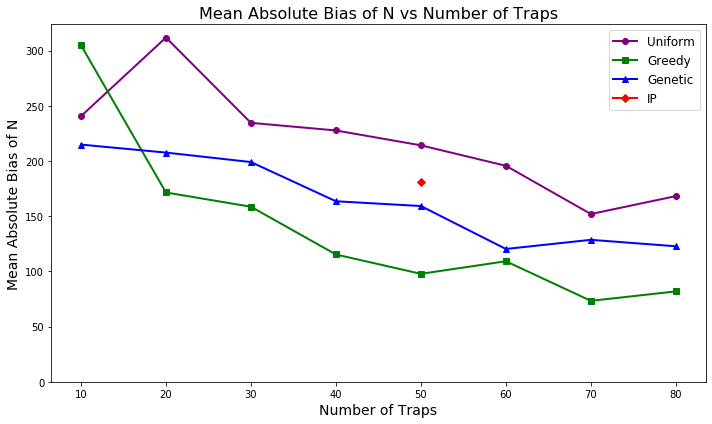

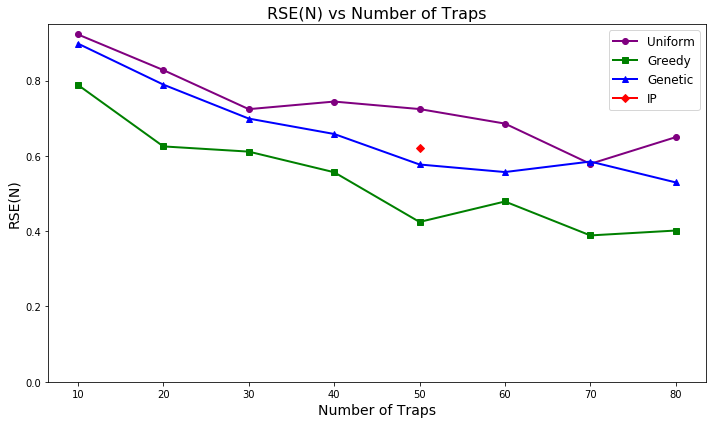

In [80]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# Folder paths and trap counts
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE'
ip_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten/Jan9_3trap_TESTING/test_results'

trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]


# Function for RSE confidence interval calculation
def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2


# Function for 95% CI calculation of mean values
def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci


# Process RSE data for Uniform and Greedy (unchanged)
def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


# Genetic Algorithm RSE
def process_genetic_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


# NEW: Integer Programming RSE (IP-##traps_SA#_test_RSE.csv)
def process_ip_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        # Two-digit trap count, then 'traps', then '_SA', a single digit, then '_test_RSE.csv'
        pattern = f'IP4-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


# Process Mean Absolute Bias data
def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


def process_genetic_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


# NEW: Integer Programming bias (same IP pattern)
def process_ip_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP4-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)


# Load all data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
genetic_rse_means, genetic_rse_cis = process_genetic_rse(genetic_folder)
ip_rse_means, ip_rse_cis = process_ip_rse(ip_folder)

uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)
genetic_bias_means, genetic_bias_cis = process_genetic_bias(genetic_folder)
ip_bias_means, ip_bias_cis = process_ip_bias(ip_folder)

# Create two separate figures
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Bias plot (first figure)
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple',
         label='Uniform', linewidth=2)
# ax1.fill_between(
#     trap_counts,
#     np.maximum(uniform_bias_means - uniform_bias_cis, 0),
#     uniform_bias_means + uniform_bias_cis,
#     color='purple', alpha=0.2
# )

ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green',
         label='Greedy', linewidth=2)
# ax1.fill_between(
#     trap_counts,
#     np.maximum(greedy_bias_means - greedy_bias_cis, 0),
#     greedy_bias_means + greedy_bias_cis,
#     color='green', alpha=0.2
# )

ax1.plot(trap_counts, genetic_bias_means, marker='^', color='blue',
         label='Genetic', linewidth=2)
# ax1.fill_between(
#     trap_counts,
#     np.maximum(genetic_bias_means - genetic_bias_cis, 0),
#     genetic_bias_means + genetic_bias_cis,
#     color='blue', alpha=0.2
# )

ax1.plot(trap_counts, ip_bias_means, marker='D', color='red',
         label='IP', linewidth=2)
# ax1.fill_between(
#     trap_counts,
#     np.maximum(ip_bias_means - ip_bias_cis, 0),
#     ip_bias_means + ip_bias_cis,
#     color='red', alpha=0.2
# )

ax1.set_xlabel('Number of Traps', fontsize=14)
ax1.set_ylabel('Mean Absolute Bias of N', fontsize=14, color='black')
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(False)
plt.title('Mean Absolute Bias of N vs Number of Traps', fontsize=16)

plt.tight_layout()
plt.savefig('marten_bias.png', dpi=300, bbox_inches='tight')
plt.show()

# Second figure for RSE
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple',
         label='Uniform', linewidth=2)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green',
         label='Greedy', linewidth=2)
ax2.plot(trap_counts, genetic_rse_means, marker='^', color='blue',
         label='Genetic', linewidth=2)
ax2.plot(trap_counts, ip_rse_means, marker='D', color='red',
         label='IP', linewidth=2)

ax2.set_xlabel('Number of Traps', fontsize=14)
ax2.set_ylabel('RSE(N)', fontsize=14, color='black')
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=12, loc='upper right')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(False)
plt.title('RSE(N) vs Number of Traps', fontsize=16)

plt.tight_layout()
plt.savefig('marten_rse.png', dpi=300, bbox_inches='tight')
plt.show()


Uniform MPAE: [160.39030932 207.89025319 156.38357608 151.79098057 142.80508061
 130.45596649 101.32240961 112.13902727]
Greedy MPAE: [203.30096992 114.33911035 105.72913131  76.8842261   65.21289038
  72.79960037  48.90149778  54.58429232]
Genetic MPAE: [143.25762915 138.43053606 132.71236881 109.03332636 106.14877217
  80.21445426  85.74720804  81.84012111]
IP (j=3) MPAE: [169.74374339 169.27584538 134.70616135          nan 120.86153302
          nan  97.41297807          nan]
IP (j=4) MPAE: [151.54448874 165.0157452  121.98241905          nan 111.74786472
          nan  93.24954507          nan]


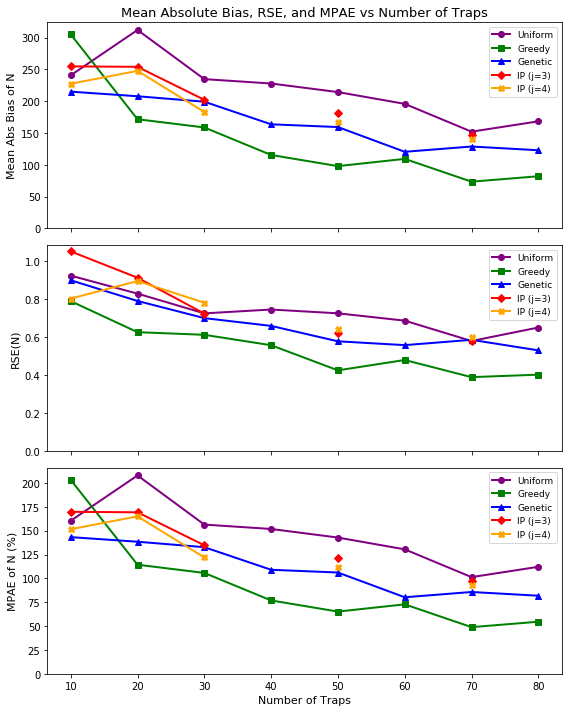

In [117]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Folder paths and trap counts
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE'

# Existing IP (j=3)
ip_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten/Jan9_3trap_TESTING/test_results'
# NEW IP (j=4) – updated path
ip4_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten/Jan10_4trap_TESTING/test_results'

trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# ------------------------------------------------------------------
# Helper: mean percent absolute error (as percentage, not fraction)
# ------------------------------------------------------------------

def calc_mpae(values, true_vals=None, true_N=None):
    """
    values: array-like of absolute errors (e.g., N_abs_error)
    true_vals: array-like of true N for each row (if available)
    true_N: scalar true N, if constant across all rows
    Returns: (mean_percent_abs_error, half_width_95CI)
    """
    values = np.array(values, dtype=float)
    if values.size == 0:
        return np.nan, 0.0

    if true_vals is not None:
        true_vals = np.array(true_vals, dtype=float)
        denom = true_vals
    elif true_N is not None:
        denom = np.full_like(values, fill_value=true_N, dtype=float)
    else:
        raise ValueError("Either true_vals or true_N must be provided to calc_mpae.")

    # avoid divide-by-zero
    mask = np.isfinite(values) & np.isfinite(denom) & (denom != 0)
    values = values[mask]
    denom = denom[mask]

    if values.size == 0:
        return np.nan, 0.0

    pct_errors = 100.0 * values / denom  # percent

    mean_val, ci = calc_95ci(pct_errors)
    return mean_val, ci

# ------------------------------------------------------------------
# Existing helpers
# ------------------------------------------------------------------

def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

# ------------------------------------------------------------------
# RSE processing
# ------------------------------------------------------------------

def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_genetic_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Existing IP = IP (j=3)
def process_ip_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP4-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# NEW IP (j=4)
def process_ip4_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP5-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# ------------------------------------------------------------------
# Absolute bias
# ------------------------------------------------------------------

def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_genetic_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Existing IP (j=3)
def process_ip_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP4-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# NEW IP (j=4)
def process_ip4_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP5-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# ------------------------------------------------------------------
# Mean percent absolute error (MPAE)
# ------------------------------------------------------------------

USE_TRUE_COLUMN = False
TRUE_N = 150  # <-- set this to your true N if constant

def process_uniform_mpae(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        pooled_true = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
            if USE_TRUE_COLUMN:
                pooled_true.extend(df['N_true'].values)
        if USE_TRUE_COLUMN:
            mean_val, ci = calc_mpae(pooled_errors, true_vals=pooled_true)
        else:
            mean_val, ci = calc_mpae(pooled_errors, true_N=TRUE_N)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_mpae(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        pooled_true = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
            if USE_TRUE_COLUMN:
                pooled_true.extend(df['N_true'].values)
        if USE_TRUE_COLUMN:
            mean_val, ci = calc_mpae(pooled_errors, true_vals=pooled_true)
        else:
            mean_val, ci = calc_mpae(pooled_errors, true_N=TRUE_N)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_genetic_mpae(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        pooled_true = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
            if USE_TRUE_COLUMN:
                pooled_true.extend(df['N_true'].values)
        if USE_TRUE_COLUMN:
            mean_val, ci = calc_mpae(pooled_errors, true_vals=pooled_true)
        else:
            mean_val, ci = calc_mpae(pooled_errors, true_N=TRUE_N)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Existing IP (j=3)
def process_ip_mpae(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP4-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        pooled_true = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
            if USE_TRUE_COLUMN:
                pooled_true.extend(df['N_true'].values)
        if USE_TRUE_COLUMN:
            mean_val, ci = calc_mpae(pooled_errors, true_vals=pooled_true)
        else:
            mean_val, ci = calc_mpae(pooled_errors, true_N=TRUE_N)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# NEW IP (j=4)
def process_ip4_mpae(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'IP5-{n:02d}traps_SA*_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        pooled_true = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
            if USE_TRUE_COLUMN:
                pooled_true.extend(df['N_true'].values)
        if USE_TRUE_COLUMN:
            mean_val, ci = calc_mpae(pooled_errors, true_vals=pooled_true)
        else:
            mean_val, ci = calc_mpae(pooled_errors, true_N=TRUE_N)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# ------------------------------------------------------------------
# Load all data
# ------------------------------------------------------------------

uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
genetic_rse_means, genetic_rse_cis = process_genetic_rse(genetic_folder)
ip_rse_means, ip_rse_cis = process_ip_rse(ip_folder)      # IP (j=3)
ip4_rse_means, ip4_rse_cis = process_ip4_rse(ip4_folder)  # IP (j=4)

uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)
genetic_bias_means, genetic_bias_cis = process_genetic_bias(genetic_folder)
ip_bias_means, ip_bias_cis = process_ip_bias(ip_folder)      # IP (j=3)
ip4_bias_means, ip4_bias_cis = process_ip4_bias(ip4_folder)  # IP (j=4)

# MPAE
uniform_mpae_means, uniform_mpae_cis = process_uniform_mpae(uniform_folder)
greedy_mpae_means, greedy_mpae_cis = process_greedy_mpae(greedy_folder)
genetic_mpae_means, genetic_mpae_cis = process_genetic_mpae(genetic_folder)
ip_mpae_means, ip_mpae_cis = process_ip_mpae(ip_folder)      # IP (j=3)
ip4_mpae_means, ip4_mpae_cis = process_ip4_mpae(ip4_folder)  # IP (j=4)

print("Uniform MPAE:", uniform_mpae_means)
print("Greedy MPAE:", greedy_mpae_means)
print("Genetic MPAE:", genetic_mpae_means)
print("IP (j=3) MPAE:", ip_mpae_means)
print("IP (j=4) MPAE:", ip4_mpae_means)

# ------------------------------------------------------------------
# Combined subplots (bias, RSE, MPAE)
# ------------------------------------------------------------------

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

ax1, ax2, ax3 = axes  # unpack

# ----- Bias -----
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple',
         label='Uniform', linewidth=2)
ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green',
         label='Greedy', linewidth=2)
ax1.plot(trap_counts, genetic_bias_means, marker='^', color='blue',
         label='Genetic', linewidth=2)
ax1.plot(trap_counts, ip_bias_means, marker='D', color='red',
         label='IP (j=3)', linewidth=2)
ax1.plot(trap_counts, ip4_bias_means, marker='X', color='orange',
         label='IP (j=4)', linewidth=2)

ax1.set_ylabel('Mean Abs Bias of N', fontsize=11, color='black')
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=9, loc='upper right')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(False)
ax1.set_title('Mean Absolute Bias, RSE, and MPAE vs Number of Traps', fontsize=13)

# ----- RSE -----
ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple',
         label='Uniform', linewidth=2)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green',
         label='Greedy', linewidth=2)
ax2.plot(trap_counts, genetic_rse_means, marker='^', color='blue',
         label='Genetic', linewidth=2)
ax2.plot(trap_counts, ip_rse_means, marker='D', color='red',
         label='IP (j=3)', linewidth=2)
ax2.plot(trap_counts, ip4_rse_means, marker='X', color='orange',
         label='IP (j=4)', linewidth=2)

ax2.set_ylabel('RSE(N)', fontsize=11, color='black')
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=9, loc='upper right')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(False)

# ----- MPAE -----
ax3.plot(trap_counts, uniform_mpae_means, marker='o', color='purple',
         label='Uniform', linewidth=2)
ax3.plot(trap_counts, greedy_mpae_means, marker='s', color='green',
         label='Greedy', linewidth=2)
ax3.plot(trap_counts, genetic_mpae_means, marker='^', color='blue',
         label='Genetic', linewidth=2)
ax3.plot(trap_counts, ip_mpae_means, marker='D', color='red',
         label='IP (j=3)', linewidth=2)
ax3.plot(trap_counts, ip4_mpae_means, marker='X', color='orange',
         label='IP (j=4)', linewidth=2)

ax3.set_xlabel('Number of Traps', fontsize=11)
ax3.set_ylabel('MPAE of N (%)', fontsize=11, color='black')
ax3.set_ylim(bottom=0)
ax3.legend(fontsize=9, loc='upper right')
ax3.tick_params(axis='y', labelcolor='black')
ax3.grid(False)

plt.tight_layout()
plt.savefig('marten_all_subplots.png', dpi=300, bbox_inches='tight')
plt.show()


Improved Genetic Algorithm total excluded: [50 34  7  4  6  0  2  1]
Existing Genetic Algorithm total excluded: [334 181 145  82  56  28  20  20]


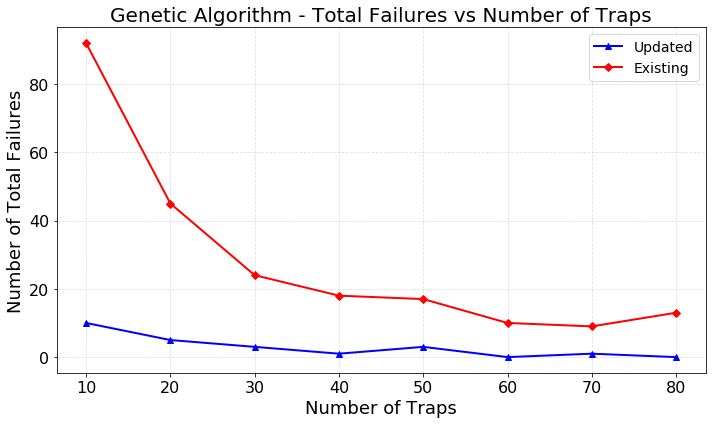

In [ ]:

# ------------------------------------------------------------
# Helpers to compute failures / excluded runs
# ------------------------------------------------------------

def compute_failure_stats_old_genetic(folder, trap_counts, error_threshold=1000, runs_per_file=150):
    total_failures = []
    failures = []
    total_excluded = []

    for n in trap_counts:
        pattern = f"SAA3-SA*-{n}traps_test_RSE.csv"
        file_paths = glob.glob(os.path.join(folder, pattern))

        rows_before_filter = 0
        rows_filtered = 0

        for path in file_paths:
            df = pd.read_csv(path)
            rows_before_filter += len(df)
            rows_filtered += np.sum(df["N_abs_error"] > error_threshold)

        total_runs = runs_per_file * len(file_paths)
        total_fail = total_runs - rows_before_filter

        total_failures.append(total_fail)
        failures.append(rows_filtered)
        total_excluded.append(total_fail + rows_filtered)

    return (
        np.array(total_failures),
        np.array(failures),
        np.array(total_excluded),
    )


fname_re_new = re.compile(r"Genetic-(\d+)traps_row(\d+)_test_RSE\.csv")

def compute_failure_stats_new_genetic(folder, trap_counts, error_threshold=1000, runs_per_file=150):
    total_failures = []
    failures = []
    total_excluded = []

    for n in trap_counts:
        pattern = os.path.join(folder, f"Genetic-{n}traps_row*_test_RSE.csv")
        file_paths = glob.glob(pattern)

        rows_before_filter = 0
        rows_filtered = 0

        for path in file_paths:
            df = pd.read_csv(path)
            rows_before_filter += len(df)
            rows_filtered += np.sum(df["N_abs_error"] > error_threshold)

        total_runs = runs_per_file * len(file_paths)
        total_fail = total_runs - rows_before_filter

        total_failures.append(total_fail)
        failures.append(rows_filtered)
        total_excluded.append(total_fail + rows_filtered)

    return (
        np.array(total_failures),
        np.array(failures),
        np.array(total_excluded),
    )


# ------------------------------------------------------------
# Compute stats for both methods
# ------------------------------------------------------------

old_total_fail, old_fail, old_excl = compute_failure_stats_old_genetic(
    old_genetic_folder, trap_counts, error_threshold=ERROR_THRESHOLD, runs_per_file=150
)
new_total_fail, new_fail, new_excl = compute_failure_stats_new_genetic(
    new_genetic_folder, trap_counts, error_threshold=ERROR_THRESHOLD, runs_per_file=150
)

print("Improved Genetic Algorithm total excluded:", old_excl)
print("Existing Genetic Algorithm total excluded:", new_excl)


# ------------------------------------------------------------
# Plot: total failures vs traps for both methods, with larger fonts
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    trap_counts, old_total_fail,
    marker="^", color="blue", linestyle="-", linewidth=2,
    label="Updated",
)
ax.plot(
    trap_counts, new_total_fail,
    marker="D", color="red", linestyle="-", linewidth=2,
    label="Existing",
)

# Larger axis labels and title
ax.set_xlabel("Number of Traps", fontsize=18)
ax.set_ylabel("Number of Total Failures", fontsize=18)
ax.set_title(
    "Genetic Algorithm - Total Failures vs Number of Traps",
    fontsize=20
)

# Larger tick labels
ax.tick_params(axis="both", which="major", labelsize=16)

# Grid and legend with larger font
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=14, loc="upper right")

plt.tight_layout()
plt.savefig("genetic_improved_vs_existing_total_failures.png", dpi=300, bbox_inches="tight")
plt.show()


Table for 70 traps:
   Metric  Uniform  Forward Greedy  Genetic Algorithm
0  Beta_1     0.64            0.77               1.33
1  Beta_2     0.59            0.48               0.56
2   Sigma   141.53           79.90              98.02
3      g0     0.11            0.11               0.10


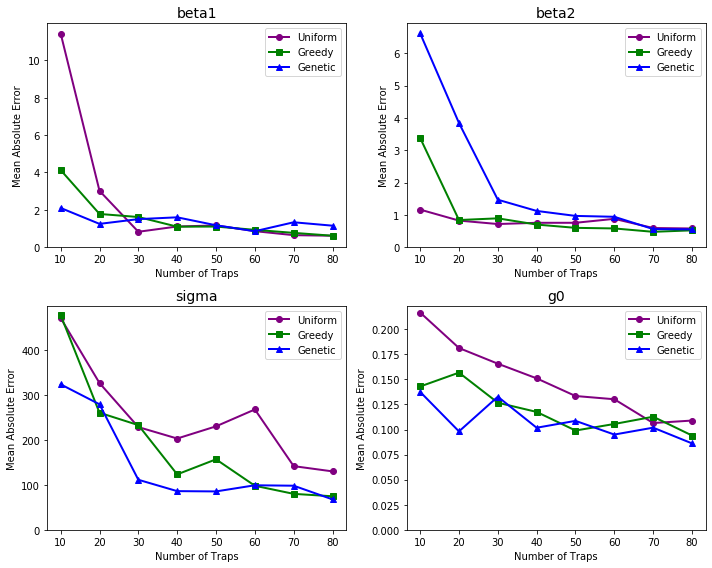

In [9]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]
error_threshold = 1000

# Function to compute mean errors for specified metrics across all trap counts
def compute_mean_errors_all_traps(folder, trap_counts, error_threshold=1000):
    metrics = ['beta1_abs_error', 'beta2_abs_error', 'sigma_abs_error', 'g0_abs_error']
    results = {metric: [] for metric in metrics}
    
    for trap_count in trap_counts:
        totals = {metric: 0.0 for metric in metrics}
        count = 0

        # Determine pattern based on folder type
        if 'SA2' in folder and 'Genetic' not in folder:
            pattern = f'SA2-*-{trap_count}traps_test.csv'
        elif 'Genetic' in folder or 'SAA3' in folder:
            pattern = f'SAA3-SA*-{trap_count}traps_test_RSE.csv'
        else:  # Uniform
            pattern = f'U_{trap_count:02d}A_1km_SAA2_A.csv'
        
        file_paths = glob.glob(os.path.join(folder, pattern))
        for file_path in file_paths:
            df = pd.read_csv(file_path)
            df_filtered = df[df['N_abs_error'] <= error_threshold]
            count += len(df_filtered)
            for metric in metrics:
                totals[metric] += df_filtered[metric].sum()

        # Compute mean for each metric
        means = {metric: totals[metric] / count if count > 0 else np.nan for metric in metrics}
        for metric in metrics:
            results[metric].append(means[metric])
    
    return {metric: np.array(values) for metric, values in results.items()}

# Compute for all three methods across all trap counts
uniform_errors = compute_mean_errors_all_traps(uniform_folder, trap_counts, error_threshold)
greedy_errors = compute_mean_errors_all_traps(greedy_folder, trap_counts, error_threshold)
genetic_errors = compute_mean_errors_all_traps(genetic_folder, trap_counts, error_threshold)

# === TABLE for 70 traps ===
trap_count_filter = 70
idx_70 = trap_counts.index(70)

uniform_means_70 = {k: v[idx_70] for k, v in uniform_errors.items()}
greedy_means_70 = {k: v[idx_70] for k, v in greedy_errors.items()}
genetic_means_70 = {k: v[idx_70] for k, v in genetic_errors.items()}

results_df = pd.DataFrame({
    'Metric': ['Beta_1', 'Beta_2', 'Sigma', 'g0'],
    'Uniform': [
        uniform_means_70['beta1_abs_error'],
        uniform_means_70['beta2_abs_error'],
        uniform_means_70['sigma_abs_error'],
        uniform_means_70['g0_abs_error']
    ],
    'Forward Greedy': [
        # greedy_means_70['N_abs_error'],
        greedy_means_70['beta1_abs_error'],
        greedy_means_70['beta2_abs_error'],
        greedy_means_70['sigma_abs_error'],
        greedy_means_70['g0_abs_error']
    ],
    'Genetic Algorithm': [
        # genetic_means_70['N_abs_error'],
        genetic_means_70['beta1_abs_error'],
        genetic_means_70['beta2_abs_error'],
        genetic_means_70['sigma_abs_error'],
        genetic_means_70['g0_abs_error']
    ]
})

print("Table for 70 traps:")
print(results_df.round(2))

# === LINE PLOTS for all metrics ===
metrics = ['beta1_abs_error', 'beta2_abs_error', 'sigma_abs_error', 'g0_abs_error']
colors = {'Uniform': 'purple', 'Forward Greedy': 'green', 'Genetic Algorithm': 'blue'}
# linestyles = {'beta1_abs_error': '--', 'beta2_abs_error': '-.', 'sigma_abs_error': ':', 'g0_abs_error': '-'}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Plot each method
    ax.plot(trap_counts, uniform_errors[metric], 
            marker='o', color=colors['Uniform'],
            linewidth=2, label='Uniform')
    ax.plot(trap_counts, greedy_errors[metric], 
            marker='s', color=colors['Forward Greedy'],
            linewidth=2, label='Greedy')
    ax.plot(trap_counts, genetic_errors[metric], 
            marker='^', color=colors['Genetic Algorithm'],
            linewidth=2, label='Genetic')
    
    ax.set_title(metric.replace('_abs_error', ''), fontsize=14)
    ax.set_xlabel('Number of Traps')
    ax.set_ylabel('Mean Absolute Error')
    ax.set_ylim(bottom=0)
    ax.legend()
    # ax.grid(True, alpha=0.3)

# Remove empty subplot
# axes[-1].remove()
plt.tight_layout()
plt.savefig('all_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [146]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import glob
import os

# Your existing folder paths and trap_counts
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def get_pooled_bias(folder, filter_large_errors=True):
    """Returns dict {n_traps: array of all N_abs_error values}"""
    bias_pools = {}
    for n in trap_counts:
        # EXACT patterns from your original processing functions
        if 'uniform' in folder.lower():
            pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        elif 'SA2' in folder or 'greedy' in folder.lower():
            pattern = f'SA2-*-{n}traps_test_RSE.csv'
        elif 'genetic' in folder.lower():
            pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        else:
            continue
            
        pooled_errors = []
        file_paths = glob.glob(os.path.join(folder, pattern))
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        bias_pools[n] = np.array(pooled_errors)
    return bias_pools

def get_pooled_n_mod(folder, filter_large_errors=True):
    """Returns dict {n_traps: array of all N_mod values}"""
    nmod_pools = {}
    for n in trap_counts:
        if 'uniform' in folder.lower():
            pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        elif 'SA2' in folder or 'greedy' in folder.lower():
            pattern = f'SA2-*-{n}traps_test_RSE.csv'
        elif 'genetic' in folder.lower():
            pattern = f'SAA3-SA*-{n}traps_test_RSE.csv'
        else:
            continue
            
        pooled_nestimates = []
        file_paths = glob.glob(os.path.join(folder, pattern))
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        nmod_pools[n] = np.array(pooled_nestimates)
    return nmod_pools

# Load data (REMOVED unused pattern_template parameter)
print("Loading pooled data...")
uniform_bias = get_pooled_bias(uniform_folder)
greedy_bias = get_pooled_bias(greedy_folder)  
genetic_bias = get_pooled_bias(genetic_folder)

uniform_nmod = get_pooled_n_mod(uniform_folder)
greedy_nmod = get_pooled_n_mod(greedy_folder)
genetic_nmod = get_pooled_n_mod(genetic_folder)

# BIAS p-values with significance
print("\n=== MEAN ABSOLUTE BIAS p-values ===")
print("Traps\tUvsG\tGvsGA\tUvsGA")
for n in trap_counts:
    u, g, ga = uniform_bias[n], greedy_bias[n], genetic_bias[n]
    if len(u)>1 and len(g)>1 and len(ga)>0:
        p_ug = ttest_ind(u, g, equal_var=False).pvalue
        p_ga = ttest_ind(g, ga, equal_var=False).pvalue  
        p_uga = ttest_ind(u, ga, equal_var=False).pvalue
        
        # Add stars: * = p<0.05, ** = p<0.01
        ug_sig = '*' if p_ug < 0.05 else ('**' if p_ug < 0.01 else '')
        ga_sig = '*' if p_ga < 0.05 else ('**' if p_ga < 0.01 else '')
        uga_sig = '*' if p_uga < 0.05 else ('**' if p_uga < 0.01 else '')
        
        print(f"{n}\t{p_ug:.3f}{ug_sig}\t{p_ga:.3f}{ga_sig}\t{p_uga:.3f}{uga_sig}")

# RSE p-values with significance  
print("\n=== RSE p-values ===")
print("Traps\tUvsG\tGvsGA\tUvsGA")
for n in trap_counts:
    u, g, ga = uniform_nmod[n], greedy_nmod[n], genetic_nmod[n]
    if len(u)>1 and len(g)>1 and len(ga)>0:
        p_ug = ttest_ind(u, g, equal_var=False).pvalue
        p_ga = ttest_ind(g, ga, equal_var=False).pvalue
        p_uga = ttest_ind(u, ga, equal_var=False).pvalue
        
        ug_sig = '*' if p_ug < 0.05 else ('**' if p_ug < 0.01 else '')
        ga_sig = '*' if p_ga < 0.05 else ('**' if p_ga < 0.01 else '')
        uga_sig = '*' if p_uga < 0.05 else ('**' if p_uga < 0.01 else '')
        
        print(f"{n}\t{p_ug:.3f}{ug_sig}\t{p_ga:.3f}{ga_sig}\t{p_uga:.3f}{uga_sig}")



Loading pooled data...

=== MEAN ABSOLUTE BIAS p-values ===
Traps	UvsG	GvsGA	UvsGA
10	0.108	0.021*	0.413
20	0.000*	0.149	0.001*
30	0.003*	0.078	0.157
40	0.000*	0.006*	0.009*
50	0.000*	0.000*	0.018*
60	0.000*	0.476	0.000*
70	0.000*	0.000*	0.196
80	0.000*	0.001*	0.017*

=== RSE p-values ===
Traps	UvsG	GvsGA	UvsGA
10	0.009*	0.005*	0.854
20	0.344	0.017*	0.006*
30	0.601	0.628	0.358
40	0.042*	0.276	0.282
50	0.734	0.337	0.682
60	0.362	0.618	0.210
70	0.294	0.151	0.761
80	0.088	0.211	0.526


In [76]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# For each trap count, create long-format DataFrame
def anova_tukey_bias(trap_count):
    data = []
    for method, pool_dict in [('Uniform', uniform_bias), 
                             ('Greedy', greedy_bias), 
                             ('Genetic', genetic_bias)]:
        data.extend([[method, val] for val in pool_dict[trap_count]])
    df = pd.DataFrame(data, columns=['Method', 'Bias'])
    
    # 1. ANOVA (overall test)
    groups = [df[df['Method']==m]['Bias'].values for m in df['Method'].unique()]
    f_stat, p_anova = f_oneway(*groups)
    print(f"Traps {trap_count}: ANOVA F={f_stat:.2f}, p={p_anova:.3f}")
    
    # 2. Tukey HSD (all pairwise, corrected)
    tukey = pairwise_tukeyhsd(df['Bias'], df['Method'], alpha=0.05)
    print(tukey)
    return tukey

# Run for each trap count
for n in trap_counts:
    if all(len(d[n])>1 for d in [uniform_bias, greedy_bias, genetic_bias]):
        anova_tukey_bias(n)


Traps 10: ANOVA F=3.27, p=0.040
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj    lower    upper   reject
---------------------------------------------------------
Genetic  Greedy   90.065 0.0354    4.9107 175.2194   True
Genetic Uniform   25.699 0.7347  -59.0731 110.4711  False
 Greedy Uniform  -64.366 0.1915 -151.5382  22.8062  False
---------------------------------------------------------
Traps 20: ANOVA F=12.26, p=0.000
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2 meandiff p-adj    lower    upper   reject
---------------------------------------------------------
Genetic  Greedy -36.1371 0.4547 -106.9719  34.6976  False
Genetic Uniform 104.1896 0.0022   32.0064 176.3728   True
 Greedy Uniform 140.3267  0.001   71.5892 209.0642   True
---------------------------------------------------------
Traps 30: ANOVA F=4.88, p=0.008
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lo

In [ ]:
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_count_filter = 70
error_threshold = 1000

# Function to compute mean errors for specified metrics
def compute_mean_errors(folder, trap_count, error_threshold=1000):
    metrics = ['N_abs_error', 'beta1_abs_error', 'beta2_abs_error', 'sigma_abs_error', 'g0_abs_error']
    totals = {metric: 0.0 for metric in metrics}
    count = 0

    if 'SA2' in folder:
        pattern = f'SA2-*-{trap_count}traps_test.csv'
    else:
        pattern = f'U_{trap_count:02d}A_1km_SAA2_A.csv'
    file_paths = glob.glob(os.path.join(folder, pattern))
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_filtered = df[df['N_abs_error'] <= error_threshold]
        count += len(df_filtered)
        for metric in metrics:
            totals[metric] += df_filtered[metric].sum()

    # Compute mean for each metric
    means = {metric: totals[metric] / count if count > 0 else np.nan for metric in metrics}
    return means

# Compute for uniform
uniform_means = compute_mean_errors(uniform_folder, trap_count_filter, error_threshold)

# Compute for greedy
greedy_means = compute_mean_errors(greedy_folder, trap_count_filter, error_threshold)

# Build results table
results_df = pd.DataFrame({
    'Metric': ['N', 'beta1', 'beta2', 'sigma', 'g0'],
    'Uniform': [
        uniform_means['N_abs_error'],
        uniform_means['beta1_abs_error'],
        uniform_means['beta2_abs_error'],
        uniform_means['sigma_abs_error'],
        uniform_means['g0_abs_error']
    ],
    'Forward Greedy': [
        greedy_means['N_abs_error'],
        greedy_means['beta1_abs_error'],
        greedy_means['beta2_abs_error'],
        greedy_means['sigma_abs_error'],
        greedy_means['g0_abs_error']
    ]
})

print(results_df)


  Metric     Uniform  Forward Greedy
0      N  151.983614       73.761040
1  beta1    0.644188        0.766715
2  beta2    0.593422        0.475763
3  sigma  141.527847       79.900484
4     g0    0.106487        0.112761


In [4]:
import os
import glob
import pandas as pd
import numpy as np

# Folder containing the SA2 results
folder_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results'

# Search pattern for expected filenames
file_paths = glob.glob(os.path.join(folder_path, 'SA2-*-*traps_val.csv'))

records = []

for path in file_paths:
    filename = os.path.basename(path)
    # Expected format: SA2-#-##traps_val.csv
    parts = filename.replace('.csv', '').split('-')
    
    # Extract run number and trap count
    run_id = parts[1]
    trap_str = parts[2].replace('traps_val', '')
    num_traps = int(trap_str)
    
    # Load the dataset
    df = pd.read_csv(path)
    if 'N_abs_error' not in df.columns:
        continue
    
    # Filter and compute mean error
    df_filtered = df[df['N_abs_error'] <= 1000]
    mean_error = np.mean(df_filtered['N_abs_error']) if len(df_filtered) > 0 else np.nan
    
    # One summary row per file
    records.append([f'SA2-{run_id}', num_traps, mean_error])

# Build summary DataFrame with 160 rows (20 runs × 8 trap levels)
output_df = pd.DataFrame(records, columns=['Run_ID', 'Num_Traps', 'Mean_Filtered_N_abs_error'])

# Save output to same directory
output_path = os.path.join(folder_path, 'SA2_filtered_mean_errors.csv')
output_df.to_csv(output_path, index=False)

print(f'Summary saved to {output_path} with {len(output_df)} rows (expected 160).')


Summary saved to /Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results/SA2_filtered_mean_errors.csv with 159 rows (expected 160).


In [59]:
import numpy as np
import pandas as pd
import pyreadr

# -----------------------------
# User-editable paths
# -----------------------------
ac_path = './full_grid_1km/10-3 data (Marten)/500m_mask_marten.RDS'
trap_path = './full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv'
params_path = './full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv'

K = 5  # number of occasions


def main():
    # Read activity centers
    ac_raw = pyreadr.read_r(ac_path)
    ac_df = ac_raw[None]          # extract the single R object
    ac_coords = ac_df[['x', 'y']].values

    # Read traps
    trap_df = pd.read_csv(trap_path).drop(columns=['Unnamed: 0'])
    trap_coords = trap_df[['x', 'y']].values

    # Distances (J, L)
    traps = trap_coords[:, np.newaxis, :]
    centers = ac_coords[np.newaxis, :, :]
    distances = np.linalg.norm(traps - centers, axis=2)  # (num_traps, num_pixels)

    num_traps, num_pixels = distances.shape

    # Find 3 closest traps per pixel (scenario-independent)
    j1_l_spatial = np.argmin(distances, axis=0)

    distances_masked = distances.copy()
    distances_masked[j1_l_spatial, np.arange(num_pixels)] = np.inf
    j2_l_spatial = np.argmin(distances_masked, axis=0)

    distances_masked2 = distances_masked.copy()
    distances_masked2[j2_l_spatial, np.arange(num_pixels)] = np.inf
    j3_l_spatial = np.argmin(distances_masked2, axis=0)

    # Read parameter draws
    params = pd.read_csv(params_path)

    P_values = []
    Q_values = []

    for _, row in params.iterrows():
        g0 = row['g0']
        sigma = row['sigma']
        alpha1 = 1.0 / (2.0 * sigma * sigma)

        # Per-occasion capture probability P_{j,l}^s on full grid
        prob_cap = g0 * np.exp(-alpha1 * (distances ** 2))  # (J, L)

        # K-occasion capture probability Q_{j,l}^s
        Q_full = 1.0 - (1.0 - prob_cap) ** K

        # Extract only the 3 closest traps per pixel
        # shapes: (L,) for indices -> (L,) for each Pk, Qk
        P1 = prob_cap[j1_l_spatial, np.arange(num_pixels)]
        P2 = prob_cap[j2_l_spatial, np.arange(num_pixels)]
        P3 = prob_cap[j3_l_spatial, np.arange(num_pixels)]

        Q1 = Q_full[j1_l_spatial, np.arange(num_pixels)]
        Q2 = Q_full[j2_l_spatial, np.arange(num_pixels)]
        Q3 = Q_full[j3_l_spatial, np.arange(num_pixels)]

        P_values.append(P1)
        P_values.append(P2)
        P_values.append(P3)

        Q_values.append(Q1)
        Q_values.append(Q2)
        Q_values.append(Q3)

    P_all = np.concatenate(P_values)
    Q_all = np.concatenate(Q_values)

    print("P for 3 closest traps per pixel:")
    print(f"  min    = {P_all.min():.8e}")
    print(f"  median = {np.median(P_all):.8e}")
    print(f"  max    = {P_all.max():.8e}")

    print("\nQ for 3 closest traps per pixel:")
    print(f"  min    = {Q_all.min():.8e}")
    print(f"  median = {np.median(Q_all):.8e}")
    print(f"  max    = {Q_all.max():.8e}")


if __name__ == '__main__':
    main()


P for 3 closest traps per pixel:
  min    = 5.73142805e-67
  median = 7.44603779e-02
  max    = 4.61239819e-01

Q for 3 closest traps per pixel:
  min    = 0.00000000e+00
  median = 3.20835343e-01
  max    = 9.54608195e-01


### IP Unique Configurations

In [58]:
# import os
# import pandas as pd

# base_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten (A)"
# budgets = [10, 20, 30, 40, 50, 60, 70, 80]
# param_draws = [6, 7, 8, 10, 11, 16, 17, 18, 20, 23, 25, 26, 31, 34, 38, 43, 46, 47, 57, 58, 60, 61, 64, 67, 68, 69, 73, 
#       74, 76, 77, 78, 79, 80, 83, 85, 91, 93, 94, 98, 102, 105, 109, 110, 112, 114, 115, 119, 120, 125, 127, 130, 
#       145, 148, 149, 153, 155, 158, 164, 165, 166, 174, 176, 180, 181, 183, 186, 187, 193, 194, 195, 197, 204, 212, 
#       216, 219, 222, 225, 227, 230, 231, 232, 233, 234, 235, 238, 239, 240, 250, 251, 257, 267, 275, 279, 282, 283, 
#       287, 289, 290, 296, 298]

# print("Computing number of unique configurations for each budget:")

# for budget in budgets:
#     config_set = set()
#     budget_dir = os.path.join(base_dir, f"Budget = {budget}")
#     for param_id in param_draws:
#         selected_csv = os.path.join(
#             budget_dir,
#             f"IP-selected_ids-budget{budget}-param{param_id}.csv"
#         )
#         if not os.path.exists(selected_csv):
#             print(f"Warning: {selected_csv} does not exist, skipping.")
#             continue
#         df = pd.read_csv(selected_csv)
#         # Use frozenset to ensure configuration is counted regardless of order
#         config_set.add(frozenset(df['Trap_index'].tolist()))
#     print(f"Budget {budget}: {len(config_set)} unique configurations")

import os
import pandas as pd

base_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten/Jan9_3trap_TESTING"
budgets = [10, 20, 30, 40, 50, 60, 70, 80]

print("Computing number of unique configurations for each budget:")

for budget in budgets:
    config_set = set()
    budget_dir = os.path.join(base_dir, f"Budget = {budget}")

        # Look for all selected_ids files inside this Param folder
    for file in os.listdir(budget_dir):
        if file.startswith("IP-selected_ids") and file.endswith(".csv"):
            selected_csv = os.path.join(budget_dir, file)
            df = pd.read_csv(selected_csv)
            config_set.add(frozenset(df['Trap_index'].tolist()))

    print(f"Budget {budget}: {len(config_set)} unique configurations")


Computing number of unique configurations for each budget:
Budget 10: 17 unique configurations
Budget 20: 19 unique configurations
Budget 30: 20 unique configurations
Budget 40: 20 unique configurations
Budget 50: 20 unique configurations
Budget 60: 20 unique configurations
Budget 70: 20 unique configurations
Budget 80: 20 unique configurations


In [129]:
# import pandas as pd
from pathlib import Path
import re

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten/Jan10_4trap_TESTING")

# Budgets to process
budgets = [10, 20, 30, 40,50, 60, 70, 80]
all_results = []

# Loop through budgets
for budget in budgets:
    val_dir = BASE_DIR / f"Budget = {budget}" / "val_results"
    
    budget_results = []
    
    # Process all CSV files in Validation Results folder
    for csv_path in val_dir.glob("*.csv"):
        df = pd.read_csv(csv_path)
        
        # Filter out big errors (N_abs_error > 1000)
        df_filtered = df[df['N_abs_error'] <= 1000]
        
        # Calculate metrics - RSE as percentage
        mean_n_error = df_filtered['N_abs_error'].mean()
        std_n_error = df_filtered['N_abs_error'].std()
        rse_n = (std_n_error / mean_n_error) * 100
        
        # Extract SA number from filename
        sa_match = re.search(r'SA(\d+)', csv_path.name)
        sa_num = int(sa_match.group(1)) if sa_match else 0
        
        budget_results.append({
            'budget': budget,
            'sa_num': sa_num,
            'filename': csv_path.name,
            'n_valid_rows': len(df_filtered),
            'mean_N_error': mean_n_error,
            'RSE_N': rse_n
        })
    
    all_results.extend(budget_results)

# Create singular combined results DataFrame with budget column
results_df = pd.DataFrame(all_results)

# Sort by SA# first, then by budget
results_df = results_df.sort_values(['sa_num', 'budget']).reset_index(drop=True)

# for each budget, print the SA# with the lowest RSE_N
for budget in budgets:
    budget_df = results_df[results_df['budget'] == budget]
    if not budget_df.empty:
        min_rse_row = budget_df.loc[budget_df['RSE_N'].idxmin()]
        print(f"Budget {budget}: Best SA#{min_rse_row['sa_num']} with RSE_N={min_rse_row['RSE_N']:.2f}")

# Display the single DataFrame
# print("Combined Validation Results (sorted by SA#, then budget):")
# print(results_df[['sa_num', 'budget', 'filename', 'n_valid_rows', 'mean_N_error', 'RSE_N']].round(2))
# print(f"\nShape: {results_df.shape}")

results_df
results_df.to_csv(BASE_DIR / "ip_val_secr_runs.csv")


Budget 10: Best SA#4 with RSE_N=49.16
Budget 20: Best SA#4 with RSE_N=56.34
Budget 30: Best SA#10 with RSE_N=69.69
Budget 40: Best SA#6 with RSE_N=63.81
Budget 50: Best SA#4 with RSE_N=77.39
Budget 60: Best SA#6 with RSE_N=78.15
Budget 70: Best SA#3 with RSE_N=78.48
Budget 80: Best SA#6 with RSE_N=81.00


### Closest Traps per Activity Center

In [ ]:
# --------------------------------------------------------------------------------------
# USER SETTINGS
# --------------------------------------------------------------------------------------

# Paths (update if needed)
base_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr"
ac_rds_path = os.path.join(base_dir, "full_grid_1km/10-3 data (Marten)/500m_mask_marten.RDS")
trap_csv_path = os.path.join(base_dir, "full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv")


# --------------------------------------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------------------------------------

print("Reading activity center coordinates from RDS...")
ac_read = pyreadr.read_r(ac_rds_path)
# pyreadr returns a dict-like; use the first object
ac_df = list(ac_read.values())[0]
ac_coords_list = ac_df[['x', 'y']].values  # shape (num_pixels, 2)

print("Reading candidate trap locations from CSV...")
trap_coords = pd.read_csv(trap_csv_path).drop(columns=['Unnamed: 0'], errors='ignore')
trap_coords_list = trap_coords[['x', 'y']].values  # shape (num_traps, 2)

num_traps = trap_coords_list.shape[0]
num_pixels = ac_coords_list.shape[0]

print(f"Loaded {num_pixels} AC pixels and {num_traps} traps.")

# --------------------------------------------------------------------------------------
# COMPUTE DISTANCES AND CLOSEST TRAPS j1(l), j2(l)
# --------------------------------------------------------------------------------------

print("Computing distances and closest traps j1(l), j2(l)...")

# traps: (num_traps, 1, 2), centers: (1, num_pixels, 2)
traps = trap_coords_list[:, np.newaxis, :]
centers = ac_coords_list[np.newaxis, :, :]
distances = np.linalg.norm(traps - centers, axis=2)  # (num_traps, num_pixels)

# j1(l): closest trap by Euclidean distance
j1_l_spatial = np.argmin(distances, axis=0)  # length num_pixels

# j2(l): second closest trap
distances_masked = distances.copy()
distances_masked[j1_l_spatial, np.arange(num_pixels)] = np.inf
j2_l_spatial = np.argmin(distances_masked, axis=0)  # length num_pixels

print("Finished computing j1(l), j2(l).")

# --------------------------------------------------------------------------------------
# VISUALIZATION FUNCTION
# --------------------------------------------------------------------------------------

def visualize_ac_and_closest_traps(ac_coords_list, trap_coords_list,
                                   j1_l_spatial, j2_l_spatial,
                                   pixel_index=0, save_path=None):
    """
    Plot all traps, the chosen AC pixel, and its two closest traps.
    """
    traps_x = trap_coords_list[:, 0]
    traps_y = trap_coords_list[:, 1]

    ac_x = ac_coords_list[pixel_index, 0]
    ac_y = ac_coords_list[pixel_index, 1]

    j1 = j1_l_spatial[pixel_index]
    j2 = j2_l_spatial[pixel_index]

    t1_x, t1_y = trap_coords_list[j1]
    t2_x, t2_y = trap_coords_list[j2]

    plt.figure(figsize=(8, 8))

    # All traps
    plt.scatter(traps_x, traps_y, c="lightgray", s=20, label="All traps")

    # AC pixel
    plt.scatter([ac_x], [ac_y], c="red", s=60, marker="*", label=f"AC l={pixel_index}")

    # Closest traps
    plt.scatter([t1_x], [t1_y], c="blue", s=50, marker="o", label=f"j1(l)={j1}")
    plt.scatter([t2_x], [t2_y], c="green", s=50, marker="s", label=f"j2(l)={j2}")

    # Lines from AC to closest traps
    plt.plot([ac_x, t1_x], [ac_y, t1_y], color="blue", linestyle="--", linewidth=1)
    plt.plot([ac_x, t2_x], [ac_y, t2_y], color="green", linestyle="--", linewidth=1)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("AC pixel and its two closest traps")
    plt.legend(loc="best")
    plt.axis("equal")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# --------------------------------------------------------------------------------------
# RUN VISUAL CHECKS
# --------------------------------------------------------------------------------------

print("Creating diagnostic plots for selected AC pixels...")

for l in example_pixels:
    if l < 0 or l >= num_pixels:
        print(f"Skipping pixel_index={l} (out of range).")
        continue
    print(f"Visualizing pixel_index={l}, j1={j1_l_spatial[l]}, j2={j2_l_spatial[l]}")
    visualize_ac_and_closest_traps(ac_coords_list, trap_coords_list,
                                   j1_l_spatial, j2_l_spatial,
                                   pixel_index=l)


Reading activity center coordinates from RDS...


PyreadrError: File b'/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/full_grid_1km/10-3 data (Marten)/500m_mask_marten.RDS' does not exist!

### Genetic Algorithm

In [159]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Singular Opt")

# Process all budget folders
for budget_dir in BASE_DIR.glob("Budget_*"):
    if not budget_dir.is_dir():
        continue
    
    budget_id = budget_dir.name
    unselected_dir = budget_dir / "Unselected_traps"  # assuming unselected_traps are here too
    
    # Create excluded_traps subfolder
    excluded_dir = budget_dir / "excluded_traps"
    excluded_dir.mkdir(exist_ok=True)
    
    print(f"Processing {budget_dir.name}...")
    
    # Find unselected_traps files (adjust pattern if different)
    for csv_path in unselected_dir.glob("unselected_traps*.csv"):
        # Read CSV, skip first empty column, get Trap_index
        df = pd.read_csv(csv_path)
        excluded_ids = sorted(df["Trap_index"].astype(int))
        
        # Write as simple text file with one ID per line
        txt_path = excluded_dir / f"{csv_path.stem}_excluded.txt"
        with open(txt_path, 'w') as f:
            for trap_id in excluded_ids:
                f.write(f"{trap_id}\n")
        
        print(f"  Created {txt_path.name}: {len(excluded_ids)} traps")

print("Done! All excluded_traps files created.")


Processing Budget_70...
  Created unselected_traps_B70_draw5_row109_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw9_row238_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw2_row74_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw3_row76_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw8_row204_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw1_row64_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw7_row164_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw10_row250_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw4_row78_excluded.txt: 1015 traps
  Created unselected_traps_B70_draw6_row125_excluded.txt: 1015 traps
Processing Budget_40...
  Created unselected_traps_B40_draw1_row64_excluded.txt: 1045 traps
  Created unselected_traps_B40_draw4_row78_excluded.txt: 1045 traps
  Created unselected_traps_B40_draw5_row109_excluded.txt: 1045 traps
  Created unselected_traps_B40_draw9_row238_excluded.txt: 10

In [44]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

records = []

# loop over all budget folders (Budget_10 to Budget_80)
for budget_dir in BASE_DIR.glob("Budget_*"):
    if not budget_dir.is_dir():
        continue

    budget_id = int(budget_dir.name.split("_")[1])

    selected_dir = budget_dir / "Selected_traps"
    if not selected_dir.exists():
        continue

    # loop over all selected_traps_SA*.csv files (SA1 to SA20)
    for csv_path in selected_dir.glob("selected_traps_SA*.csv"):
        sa_id = csv_path.name  # Use filename as identifier (SA1, SA2, etc.)
        
        df = pd.read_csv(csv_path)

        # configuration is the sorted tuple of unique Trap_index values
        config = tuple(sorted(df["Trap_index"].unique()))

        records.append({
            "budget": budget_id,
            "sa_id": sa_id,
            "config": config,
        })

# dataframe with one row per file
df_configs = pd.DataFrame(records)

# group by budget and configuration, count occurrences
unique_configs = (
    df_configs
    .groupby(["budget", "config"], as_index=False)
    .agg(n_occurrences=("sa_id", "size"))
    .groupby("budget", as_index=False)
    .agg(n_unique_configs=("config", "size"))
)

unique_configs


,budget,n_unique_configs
0,10,17
1,20,20
2,30,20
3,40,20
4,50,20
5,60,20
6,70,20
7,80,5


In [5]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

records = []

# Filter for budget 10 only
budget_target = 10
budget_dir = BASE_DIR / f"Budget_{budget_target}"
if not budget_dir.exists():
    print(f"Budget_{budget_target} directory not found")
else:
    selected_dir = budget_dir / "Selected_traps"
    if not selected_dir.exists():
        print("Selected_traps directory not found")
    else:
        # loop over all selected_traps_SA*.csv files (SA1 to SA20)
        for csv_path in selected_dir.glob("selected_traps_SA*.csv"):
            sa_id = csv_path.name
            
            df = pd.read_csv(csv_path)
            config = tuple(sorted(df["Trap_index"].unique()))
            
            records.append({
                "file": sa_id,
                "config": config,
            })

# Create dataframe and group by config
df_configs = pd.DataFrame(records)

# Get unique configurations with their corresponding files
config_files = (
    df_configs
    .groupby("config")["file"]
    .apply(list)
    .reset_index()
)

# Print results
print(f"Unique configurations for Budget_{budget_target}:")
print(f"Total unique configs: {len(config_files)} out of 20 files\n")

for idx, row in config_files.iterrows():
    config_str = str(row["config"])[:100] + "..." if len(str(row["config"])) > 100 else str(row["config"])
    files_str = ", ".join(row["file"])
    print(f"Config {idx+1}: {config_str}")
    print(f"  Files: {files_str}")
    print()


Unique configurations for Budget_10:
Total unique configs: 17 out of 20 files

Config 1: (24, 98, 99, 133, 134, 764, 797, 798, 833, 934)
  Files: selected_traps_SA17.csv

Config 2: (27, 62, 63, 98, 99, 139, 194, 659, 798, 899)
  Files: selected_traps_SA19.csv

Config 3: (62, 63, 98, 139, 684, 718, 719, 728, 763, 899)
  Files: selected_traps_SA8.csv

Config 4: (62, 63, 99, 134, 138, 728, 763, 874, 875, 899)
  Files: selected_traps_SA18.csv

Config 5: (98, 138, 649, 683, 684, 687, 688, 722, 723, 728)
  Files: selected_traps_SA11.csv

Config 6: (98, 686, 687, 688, 721, 722, 723, 840, 874, 875)
  Files: selected_traps_SA20.csv

Config 7: (646, 684, 687, 688, 722, 839, 840, 874, 875, 1049)
  Files: selected_traps_SA16.csv

Config 8: (649, 683, 684, 685, 686, 687, 839, 840, 874, 875)
  Files: selected_traps_SA10.csv

Config 9: (649, 683, 684, 685, 719, 720, 839, 840, 874, 875)
  Files: selected_traps_SA6.csv

Config 10: (649, 683, 684, 687, 688, 839, 840, 874, 875, 1049)
  Files: selected_tr

### Prob Cap Exploration

In [92]:
# param_draws = [6, 7, 8, 10, 11, 16, 17, 18, 20, 23, 25, 26, 31, 34, 38, 43, 46, 47, 57, 58, 60, 
#               61, 64, 67, 68, 69, 73, 74, 76, 77, 78, 79, 80, 83, 85, 91, 93, 94, 98, 102, 105, 109, 110, 112, 
#               114, 115, 119, 120, 125, 127, 130, 145, 148, 149, 153, 155, 158, 164, 165, 166, 174, 176, 180, 181, 
#               183, 186, 187, 193, 194, 195, 197, 204, 212, 216, 219, 222, 225, 227, 230, 231, 232, 233, 234, 235, 
#               238, 239, 240, 250, 251, 257, 267, 275, 279, 282, 283, 287, 289, 290, 296, 298]

param_draws = list(range(1, 301))

K = 5 

# Read in activity centers
ac_coords = pyreadr.read_r('./full_grid_1km/10-3 data (Marten)/500m_mask_marten.RDS')
ac_df = next(iter(ac_coords.values()))
ac_coords_list = ac_df[['x', 'y']].values

# Read in candidate trap locations
trap_coords = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv').drop(columns=['Unnamed: 0'])
trap_coords_list = trap_coords[['x', 'y']].values
num_traps = len(trap_coords_list)

# Calculate distances between all candidate traps and activity centers
traps = trap_coords_list[:, np.newaxis, :]   
centers = ac_coords_list[np.newaxis, :, :]   
distances = np.linalg.norm(traps - centers, axis=2) 

# Extract parameter draws
params = pd.read_csv('./full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv')


num_draws = len(param_draws)
num_cells = distances.shape[1]

prob_cap_all = np.empty((num_draws, num_traps, num_cells), dtype=float)

for idx, param_id in enumerate(param_draws):
    param_row = params.iloc[param_id - 1]  # rows are 1-indexed in your original code
    g0_val = param_row['g0']
    sigma_val = param_row['sigma']

    alpha1 = 1.0 / (2.0 * sigma_val**2)
    prob_cap = g0_val * np.exp(-alpha1 * (distances**2))  # (num_traps, num_cells)

    prob_cap_all[idx, :, :] = prob_cap

# ----------------------------
# 3. Summarize distribution
# ----------------------------

flat_probs = prob_cap_all.ravel()

print("=== Capture probability distribution over all draws, traps, and cells ===")
print(f"Global min: {flat_probs.min():.8f}")
print(f"Global max: {flat_probs.max():.8f}")
print(f"Mean:       {flat_probs.mean():.8f}")
print(f"Std:        {flat_probs.std():.8f}")

# percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
# print("\nPercentiles:")
# for q in percentiles:
#     val = np.percentile(flat_probs, q)
#     print(f"{q:3d}th: {val:.8f}")

# Per-draw min/max (first few draws)
draw_mins = prob_cap_all.min(axis=(1, 2))
draw_maxs = prob_cap_all.max(axis=(1, 2))

print("\nPer-draw min/max (first 10 draws):")
for i, param_id in enumerate(param_draws[:10]):
    print(f"Draw id {param_id:3d}: min={draw_mins[i]:.8f}, max={draw_maxs[i]:.8f}")


# count how many probabilities end up being 0
zero_count = np.sum(flat_probs == 0.0000000)
total_count = flat_probs.size
print(f"\nNumber of zero probabilities: {zero_count} out of {total_count} ({(zero_count/total_count)*100:.6f}%)")



print(f"Exact zeros: {(zero_count/total_count)*100:.1f}%")
print(f"Values <= 1e-10: {np.sum(flat_probs <= 1e-10)/total_count*100:.1f}%")
print(f"Median exact: {np.median(flat_probs):.8f}")


=== Capture probability distribution over all draws, traps, and cells ===
Global min: 0.00000000
Global max: 0.46123982
Mean:       0.00049941
Std:        0.00916370

Per-draw min/max (first 10 draws):
Draw id   1: min=0.00000000, max=0.15954283
Draw id   2: min=0.00000000, max=0.30220990
Draw id   3: min=0.00000000, max=0.31683706
Draw id   4: min=0.00000000, max=0.34622071
Draw id   5: min=0.00000000, max=0.04266402
Draw id   6: min=0.00000000, max=0.37792271
Draw id   7: min=0.00000000, max=0.21456407
Draw id   8: min=0.00000000, max=0.05613988
Draw id   9: min=0.00000000, max=0.03666856
Draw id  10: min=0.00000000, max=0.23814318

Number of zero probabilities: 602469056 out of 1727754000 (34.870072%)
Exact zeros: 34.9%
Values <= 1e-10: 96.0%
Median exact: 0.00000000


Fraction of trap–cell pairs > threshold: 0.001544837980406933
Fraction of cells active: 0.9193669932177845
active_cells shape: (5308,)


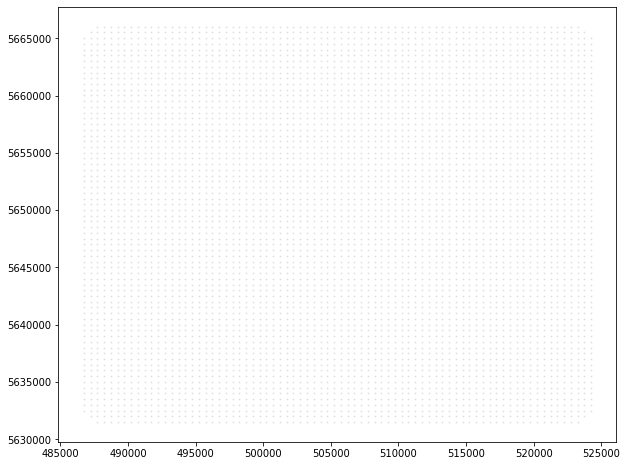

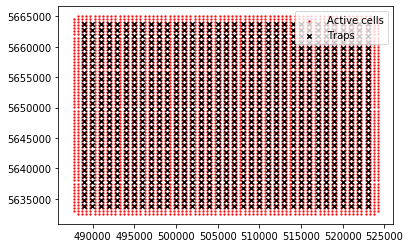

No handles with labels found to put in legend.


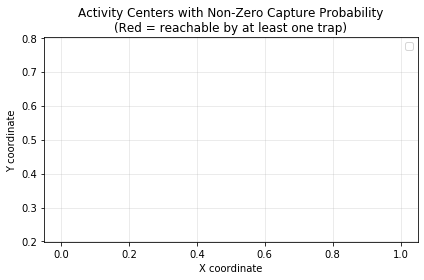

Active cells: 4880 out of 5308 total (91.9%)


In [40]:
threshold = 0.1

non_zero_mask = np.any(prob_cap_all > threshold, axis=0)   # (num_traps, num_cells)
active_cells = np.any(non_zero_mask, axis=0)               # (num_cells,)

print("Fraction of trap–cell pairs > threshold:",
      np.mean(prob_cap_all > threshold))
print("Fraction of cells active:", np.mean(active_cells))
print("active_cells shape:", active_cells.shape)


# Plot activity centers (grid cells)
plt.figure(figsize=(10, 8))

# Plot ALL activity centers as faint gray points
plt.scatter(ac_coords_list[:, 0], ac_coords_list[:, 1], 
           c='lightgray', s=1, alpha=0.5, label='All grid cells')

# Highlight ACTIVE cells (those with non-zero p_ij for at least one trap) in red

active_coords = ac_coords_list[active_cells]

plt.figure()
plt.scatter(active_coords[:, 0], active_coords[:, 1],
            c='red', s=2, alpha=0.8, label='Active cells')
plt.scatter(trap_coords_list[:, 0], trap_coords_list[:, 1],
            c='black', s=20, marker='x', label='Traps')
plt.legend()
plt.show()



# active_coords = ac_coords_list[active_cells]
# plt.scatter(active_coords[:, 0], active_coords[:, 1], 
#            c='red', s=2, alpha=0.8, label='Cells with non-zero p_ij')

# # Plot trap locations as black X's
# plt.scatter(trap_coords_list[:, 0], trap_coords_list[:, 1], 
#            c='black', s=20, marker='X', linewidth=1, label='Trap locations')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Activity Centers with Non-Zero Capture Probability\n(Red = reachable by at least one trap)')
plt.legend()
plt.axis('equal')  # Equal aspect ratio for map-like view
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Active cells: {np.sum(active_cells)} out of {len(ac_coords_list)} total ({100*np.sum(active_cells)/len(ac_coords_list):.1f}%)")


In [151]:
import pandas as pd
import glob
import os

# Directory path
dir_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/Constant_detection/D_mod'

# Find all files
files = glob.glob(os.path.join(dir_path, 'Dmod_draw_*.csv'))

# Read first file to get coordinates
df_first = pd.read_csv(files[0])
coords = df_first[['x', 'y']].drop_duplicates().sort_values(['y', 'x'])

# Initialize sum and count DataFrames with coordinates
sum_df = coords.copy()
sum_df['D_mod_sum'] = 0.0
count_df = coords.copy()
count_df['count'] = 0

# Process each file
for file in files:
    df = pd.read_csv(file)
    df = df.merge(coords, on=['x', 'y'], how='right')
    sum_df['D_mod_sum'] += df['D_mod'].fillna(0)
    count_df['count'] += df['x'].notna().astype(int)

# Calculate average
avg_df = coords.copy()
avg_df['D_mod'] = sum_df['D_mod_sum'] / count_df['count']
avg_df = avg_df[['D_mod', 'x', 'y']]  # Match original order, EN from first

# Save
avg_df.to_csv('average_D_mod.csv', index=False)
print("Saved average_D_mod.csv")


import rasterio
from rasterio.transform import from_bounds
import numpy as np

# After avg_df creation...
x_unique = sorted(avg_df['x'].unique())
y_unique = sorted(avg_df['y'].unique())[::-1]  # Reverse for raster top-to-bottom

# Grid dimensions (should be ~1000x1000 for 1km cells)
width = len(x_unique)
height = len(y_unique)

# Create 2D grid: pivot puts y as rows (descending), x as columns
grid = avg_df.pivot(index='y', columns='x', values='D_mod').values

# Key fix: from_bounds uses actual pixel bounds (centers ± 500m for 1km cells)
x_min, x_max = x_unique[0] - 500, x_unique[-1] + 500
y_min, y_max = y_unique[-1] - 500, y_unique[0] + 500  # y_unique already reversed

transform = from_bounds(x_min, y_min, x_max, y_max, width, height)

# Write with nodata for missing values
profile = {
    'driver': 'GTiff', 'height': height, 'width': width, 'count': 1,
    'dtype': grid.dtype, 'crs': 'EPSG:32610', 'transform': transform,
    'nodata': 0.0
}

with rasterio.open('average_D_mod_fixed.tif', 'w', **profile) as dst:
    dst.write(grid.astype(np.float32), 1)

print(f"Saved {width}x{height} raster with exact 1km alignment")



Saved average_D_mod.csv
Saved 76x70 raster with exact 1km alignment


In [152]:
print(f"Grid size: {len(x_unique)} x {len(y_unique)} pixels")
print(f"X range: {x_unique[0]:.0f} to {x_unique[-1]:.0f}")
print(f"Y range: {y_unique[0]:.0f} to {y_unique[-1]:.0f}")


Grid size: 76 x 70 pixels
X range: 486738 to 524238
Y range: 5666010 to 5631510


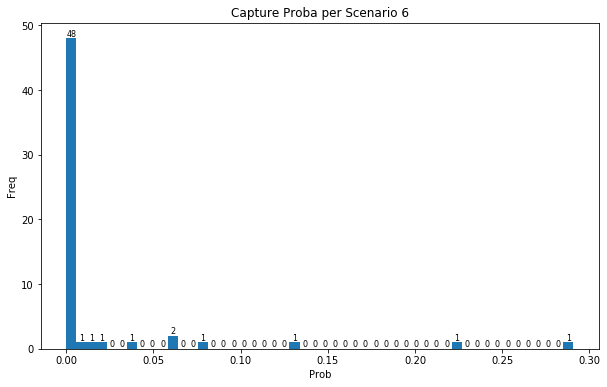

In [ ]:
# for the first draw, output a plot showing the distribution of probabilties
# remove prob < 0.5

draw_idx = 5  
prob_cap_draw = prob_cap_all[draw_idx, :, 2500] 
filtered_prob_cap_draw = prob_cap_draw[prob_cap_draw > 0.00000000000005]

plt.figure(figsize=(10, 6))
plt.hist(filtered_prob_cap_draw.ravel(), bins=50)
plt.xlabel('Prob')
plt.ylabel('Freq')
plt.title(f'Capture Proba per Scenario {param_draws[draw_idx]}')
# label bars with y axis value
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=8)
plt.show()

In [52]:
prob_cap_all.shape

(100, 1085, 5308)

In [53]:
1085*5308

5759180

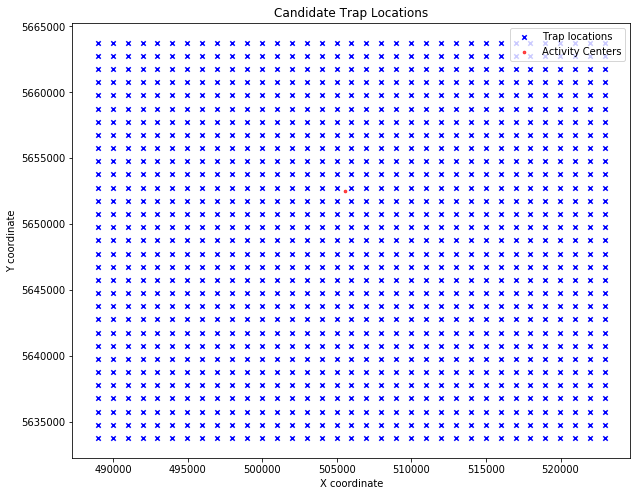

In [ ]:
# plot the potential trap locations on a map from 
trap_locs = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv').drop(columns=['Unnamed: 0'])
plt.figure(figsize=(10, 8))
plt.scatter(trap_locs['x'], trap_locs['y'], c='blue',
            s=20, marker='x', label='Trap locations')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Candidate Trap Locations')

# plot one of the activity centers in the middle from just one of the AC location files in /Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/Constant_detection/AC_locations
ac_example = pd.read_csv('./full_grid_1km/10-3 data (Marten)/Constant_detection/AC_locations/AC_draw_1.csv')

# filter ac_example for only one activity center in the middle of the grid
ac_example = ac_example[(ac_example['x'] > 505000) & (ac_example['x'] < 510000) & (ac_example['y'] > 5650000) & (ac_example['y'] < 5652500)]
# get just one randomly from this list
ac_example = ac_example.sample(n=1, random_state=1)
plt.scatter(ac_example['x'], ac_example['y'], c='red',
            s=7, alpha=0.7, label='Activity Centers')
plt.legend()
plt.show()

# calcualte the probability of capture for each of these trap locations for this one activity center
alpha1 = 1/(2 * sigma_val**2)
prob_cap = g0_val * np.exp(-alpha1 * (distances**2))  # shape (num_traps, num_cells)

Unique probability values: 1085
Min prob: 0.000000, Max prob: 0.351272


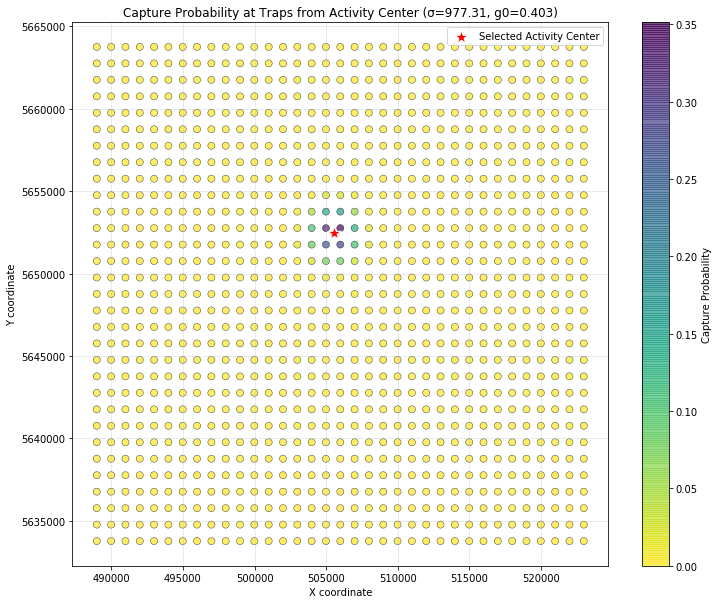

Capture probability quartiles:
              min     max    mean
quartile                         
Q1 (lowest)   0.0  0.0000  0.0000
Q2            0.0  0.0000  0.0000
Q3            0.0  0.0000  0.0000
Q4 (highest)  0.0  0.3513  0.0089


In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load trap locations and example AC (your existing code)
trap_locs = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv').drop(columns=['Unnamed: 0'])
ac_example = pd.read_csv('./full_grid_1km/10-3 data (Marten)/Constant_detection/AC_locations/AC_draw_1.csv')
ac_example = ac_example[(ac_example['x'] > 505000) & (ac_example['x'] < 510000) & 
                       (ac_example['y'] > 5650000) & (ac_example['y'] < 5652500)]
ac_example = ac_example.sample(n=1, random_state=1)

# Load parameters for draw '1' - fix for unnamed column
params = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv')
param_row = params[params.iloc[:, 0] == 6].iloc[0]  # First column (no header name)
g0_val = param_row['g0']
sigma_val = param_row['sigma']


# Calculate distances from selected AC to all trap locations
ac_point = np.array([[ac_example['x'].iloc[0], ac_example['y'].iloc[0]]])
trap_points = trap_locs[['x', 'y']].values
distances = cdist(ac_point, trap_points)[0]  # 1D array of distances to each trap

# Calculate capture probabilities
alpha1 = 1 / (2 * sigma_val**2)
prob_cap = g0_val * np.exp(-alpha1 * (distances**2))

# Add probabilities to trap_locs dataframe and create quartile bins
# Replace the quartile line with this robust fix:
trap_locs['prob_cap'] = prob_cap

# Check unique values and handle extreme case of too many zeros
unique_probs = np.unique(trap_locs['prob_cap'])
print(f"Unique probability values: {len(unique_probs)}")
print(f"Min prob: {trap_locs['prob_cap'].min():.6f}, Max prob: {trap_locs['prob_cap'].max():.6f}")

if len(unique_probs) <= 4:
    # Too many zeros - use simple rank-based quartiles instead
    trap_locs['quartile'] = pd.qcut(trap_locs['prob_cap'].rank(method='first'), q=4, 
                                   labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
else:
    trap_locs['quartile'] = pd.qcut(trap_locs['prob_cap'], q=4, 
                                   labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'], 
                                   duplicates='drop')


# Create the plot
plt.figure(figsize=(12, 10))
scatter = plt.scatter(trap_locs['x'], trap_locs['y'], c=trap_locs['prob_cap'], 
                     cmap='viridis_r', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Capture Probability')

# Plot the activity center - FIXED VISIBILITY
plt.scatter(ac_example['x'].iloc[0], ac_example['y'].iloc[0], c='red', s=200, 
           marker='*', edgecolors='white', linewidth=1, label='Selected Activity Center', 
           zorder=10)


plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title(f'Capture Probability at Traps from Activity Center (σ={sigma_val:.2f}, g0={g0_val:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print quartile statistics
print("Capture probability quartiles:")
print(trap_locs.groupby('quartile')['prob_cap'].agg(['min', 'max', 'mean']).round(4))


### Sample Average Approximation

In [35]:
#randomly select 3 sets of numbers without replacement. First, randomly select 100 numbers 1 to 300. Then, select a random 50 of the remaining 200. Then, output the remaining into the third set of 150. 
# import numpy as np
# np.random.seed(42)  # For reproducibility
# all_numbers = np.arange(1, 301)
# set1 = np.random.choice(all_numbers, size=100, replace=False)
# remaining_after_set1 = np.setdiff1d(all_numbers, set1)
# set2 = np.random.choice(remaining_after_set1, size=50, replace=False)
# set3 = np.setdiff1d(remaining_after_set1, set2)

# print("Set 1 (100 numbers):", sorted(set1))
# print("Set 2 (50 numbers):", sorted(set2))
# print("Set 3 (150 numbers):", sorted(set3))

# within set 1, randomly select 10 numbers, 20 times in python
import numpy as np
np.random.seed(42)  # For reproducibility
set1 = set1
subsets = []
for _ in range(20):
    subset = np.random.choice(set1, size=10, replace=False)
    subsets.append(sorted(subset))
for i, subset in enumerate(subsets):
    print(f"Subset {i+1}: {subset}")




Subset 1: [64, 74, 76, 78, 109, 125, 164, 204, 238, 250]
Subset 2: [31, 43, 68, 79, 91, 98, 212, 222, 289, 298]
Subset 3: [112, 114, 115, 125, 158, 176, 183, 225, 283, 287]
Subset 4: [16, 25, 38, 60, 80, 145, 225, 234, 238, 275]
Subset 5: [38, 57, 68, 85, 94, 105, 130, 193, 197, 282]
Subset 6: [7, 10, 34, 47, 78, 91, 165, 193, 204, 282]
Subset 7: [57, 67, 69, 74, 112, 125, 145, 197, 230, 231]
Subset 8: [6, 26, 31, 77, 94, 120, 164, 197, 219, 222]
Subset 9: [8, 18, 20, 69, 115, 166, 174, 180, 194, 238]
Subset 10: [11, 83, 158, 197, 212, 216, 222, 239, 257, 287]
Subset 11: [6, 64, 69, 98, 112, 153, 166, 195, 204, 296]
Subset 12: [10, 57, 58, 60, 130, 148, 176, 187, 193, 231]
Subset 13: [18, 57, 61, 78, 105, 130, 183, 227, 233, 287]
Subset 14: [10, 23, 69, 91, 94, 102, 145, 197, 219, 222]
Subset 15: [17, 58, 79, 91, 145, 227, 231, 238, 257, 289]
Subset 16: [18, 34, 69, 114, 174, 176, 181, 195, 197, 282]
Subset 17: [17, 57, 149, 193, 222, 230, 231, 233, 287, 298]
Subset 18: [47, 77, 93, 94

In [ ]:
# randomly select 10 numbers between 1 and 101 20 times in python without replacement
random_params = [np.random.choice(range(1, 102), size=10, replace=False) for _ in range(20)]
random_params

[array([ 1, 97, 68, 48, 38, 75, 94, 17, 20, 64]),
 array([82, 72, 43, 76, 93, 65, 61, 99, 62, 11]),
 array([85, 69,  2, 86, 45, 49, 81, 87, 40, 22]),
 array([90, 19, 82, 34, 86, 47, 29, 92, 71,  2]),
 array([30, 82, 42, 22, 53, 73, 28, 92, 27, 70]),
 array([42, 29, 17,  3, 84, 88, 20, 99, 90, 47]),
 array([36, 45, 88, 33,  1, 61, 29, 99, 30, 75]),
 array([76,  6, 89, 24,  7, 91, 45, 83, 48, 56]),
 array([27, 76, 97, 13, 25,  6, 12,  2, 98, 67]),
 array([44, 49, 97, 43, 85, 54,  1, 69, 56, 17]),
 array([71, 53, 16, 70,  8, 87, 28, 81, 21,  3]),
 array([28,  3, 42, 31, 15, 63, 32, 64, 21, 26]),
 array([93, 61, 92, 79, 96, 72, 53,  5, 47, 90]),
 array([36, 37, 72,  5, 42, 39, 40, 67, 51, 35]),
 array([ 53, 100,  33,  60,  72,  80,  19,  26,  15,  34]),
 array([34, 93, 79, 36, 69, 94, 22, 26, 43, 13]),
 array([96, 84, 19, 88, 72,  7, 16, 43, 50, 46]),
 array([44, 76, 43, 72, 71, 17, 27, 53, 57, 73]),
 array([ 54,  13,  61,  36,  31,  66,   8,  49, 100,  63]),
 array([66,  8, 33, 49, 26, 87

In [35]:
## loop through all files in scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/SA1-1/results and conver the csv files to dataframes
data_folder = "secr/Sample Average Approximation/SA1/SA1-20/results"
# data_folder = "secr/Sample Average Approximation/SA1/TEST"


# in each dataframe for each file, look at the column 'N_abs_error'.
for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_folder, file))
        # Filter out any rows with a value in this column > 1000.
        filtered = df[df['N_abs_error'] <= 1000]
        # report the average of the remaining rows for each dataframe and print this out.
        print(f"Average N_abs_error for {file}: {filtered['N_abs_error'].mean()}")

Average N_abs_error for SA1-20_20traps_101-151.csv: 62.27013247048344
Average N_abs_error for SA1-20_70traps_101-151.csv: 8.15614276694327
Average N_abs_error for SA1-20_30traps_101-151.csv: 34.92041969288635
Average N_abs_error for SA1-20_60traps_101-151.csv: 10.719810836991032
Average N_abs_error for SA1-20_50traps_101-151.csv: 10.117680705242805
Average N_abs_error for SA1-20_10traps_101-151.csv: 87.820835919138
Average N_abs_error for SA1-20_40traps_101-151.csv: 11.994316065375203
Average N_abs_error for SA1-20_80traps_101-151.csv: 10.81092376664128


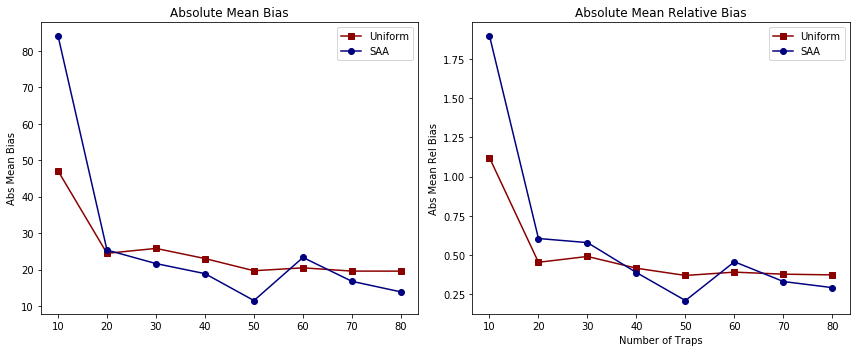

In [26]:
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Use your working uniform path and pattern
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA'

# Assuming SAA files as before
saa_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/TEST'


def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    return mean_bias, mean_rel_bias


def process_uniform_data():
    mean_biases, mean_rel_biases = [], []
    for n_traps in trap_counts:
        fname = f'U_{n_traps}A_1km_SAA_151-300.csv'
        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            continue
        mb, mrb = compute_metrics(df_filtered)
        mean_biases.append(mb)
        mean_rel_biases.append(mrb)
    return np.array(mean_biases), np.array(mean_rel_biases)


def process_saa_data():
    mean_biases, mean_rel_biases = [], []
    for n_traps in trap_counts:
        pattern = os.path.join(saa_folder, f'SA1-*_{n_traps}traps_TEST_151-300.csv')
        files = glob.glob(pattern)
        bvals, rbvals = [], []
        for path in files:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0:
                continue
            mb, mrb = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
        mb_mean = np.nanmean(bvals) if bvals else np.nan
        mrb_mean = np.nanmean(rbvals) if rbvals else np.nan
        mean_biases.append(mb_mean)
        mean_rel_biases.append(mrb_mean)
    return np.array(mean_biases), np.array(mean_rel_biases)


uniform_biases, uniform_rel_biases = process_uniform_data()
saa_biases, saa_rel_biases = process_saa_data()

trap_counts_np = np.array(trap_counts)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex='col')
titles = ['Absolute Mean Bias', 'Absolute Mean Relative Bias']
ylabels = ['Abs Mean Bias', 'Abs Mean Rel Bias']

axs[0].plot(trap_counts_np, uniform_biases, marker='s', color='darkred', label='Uniform')
axs[0].plot(trap_counts_np, saa_biases, marker='o', color='navy', label='SAA')
axs[0].legend()
axs[0].set_title(titles[0])
axs[0].set_ylabel(ylabels[0])

axs[1].plot(trap_counts_np, uniform_rel_biases, marker='s', color='darkred', label='Uniform')
axs[1].plot(trap_counts_np, saa_rel_biases, marker='o', color='navy', label='SAA')
axs[1].legend()
axs[1].set_title(titles[1])
axs[1].set_ylabel(ylabels[1])

axs[-1].set_xlabel('Number of Traps')

plt.tight_layout()
plt.show()


In [ ]:
# return a txt file that has for each row, the 